# Mobile Apps — User Segmentation Based on Behavior

**Data Description**

The dataset contains event data from the mobile application **"Unnecessary Things"**. In this application, users sell items they no longer need by posting them on a bulletin board. The data includes user activities starting from their first usage of the app after October 7, 2019.

**Columns in /datasets/mobile_sources.csv:**

- `userId` — user identifier;
- `source` — the source from which the user installed the app (e.g., Yandex, Google, etc.).

**Columns in /datasets/mobile_dataset.csv:**

- `event.time` — the time an event occurred;
- `user.id` — user identifier;
- `event.name` — name of the user's action.

**Types of actions (event.name):**

- `advert_open` — opened the advertisement card;
- `photos_show` — viewed photos in an advertisement;
- `tips_show` — saw recommended advertisements;
- `tips_click` — clicked on a recommended advertisement;
- `contacts_show` or `show_contacts` — viewed the phone number;
- `contacts_call` — called the number listed in the advertisement;
- `map` — opened the advertisement map;
- `search_1` — `search_7` — various search actions on the site (e.g., category search);
- `favorites_add` — added advertisement to favorites.

---

For further analysis, we'll use these columns to segment users, analyze their behavior, and test hypotheses.

**Project tasks:**
- Select a user segmentation method and justify it;
- Identify which user group tends to frequently return to the mobile app (retention rate);
- Identify which user group frequently performs the target action (conversion rate).

**Project Plan**
- Load and preprocess data;
- Exploratory data analysis;
- User segmentation;
- Hypothesis testing;
- Conclusions.


## Loading and preprocessing data

### Installing libraries, loading data, inspecting their contents and structure.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime, timedelta
from matplotlib import pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from matplotlib.colors import LinearSegmentedColormap

In [2]:
mobile_dataset = pd.read_csv('https://code.s3.yandex.net/datasets/mobile_dataset.csv')
mobile_sources = pd.read_csv('https://code.s3.yandex.net/datasets/mobile_sources.csv')

In [3]:
# Define a function for initial analysis of dataframes
def primary_analysis(df, exclude_columns=[]):
    # Display first 5 rows
    print("Head of the DataFrame:")
    display(df.head())
    
    # General info about the DataFrame
    print("Info:")
    df.info()
    
    # Description of numerical columns
    numerical_columns = df.select_dtypes(include=['number']
                                        ).columns.difference(exclude_columns)
    
    if not numerical_columns.empty:
        print()
        print("Description of numerical columns:")
        display(df[numerical_columns].describe())


In [4]:
primary_analysis(mobile_dataset)

Head of the DataFrame:


,event.time,event.name,user.id
0,2019-10-07 00:00:00.431357,advert_open,020292ab-89bc-4156-9acf-68bc2783f894
1,2019-10-07 00:00:01.236320,tips_show,020292ab-89bc-4156-9acf-68bc2783f894
2,2019-10-07 00:00:02.245341,tips_show,cf7eda61-9349-469f-ac27-e5b6f5ec475c
3,2019-10-07 00:00:07.039334,tips_show,020292ab-89bc-4156-9acf-68bc2783f894
4,2019-10-07 00:00:56.319813,advert_open,cf7eda61-9349-469f-ac27-e5b6f5ec475c


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74197 entries, 0 to 74196
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event.time  74197 non-null  object
 1   event.name  74197 non-null  object
 2   user.id     74197 non-null  object
dtypes: object(3)
memory usage: 1.7+ MB


In [5]:
primary_analysis(mobile_sources)

Head of the DataFrame:


,userId,source
0,020292ab-89bc-4156-9acf-68bc2783f894,other
1,cf7eda61-9349-469f-ac27-e5b6f5ec475c,yandex
2,8c356c42-3ba9-4cb6-80b8-3f868d0192c3,yandex
3,d9b06b47-0f36-419b-bbb0-3533e582a6cb,other
4,f32e1e2a-3027-4693-b793-b7b3ff274439,google


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4293 entries, 0 to 4292
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   userId  4293 non-null   object
 1   source  4293 non-null   object
dtypes: object(2)
memory usage: 67.2+ KB


### Merging datasets
Merge mobile_dataset and mobile_sources.


In [6]:
# Renaming column for consistency
mobile_dataset.rename(columns={'user.id': 'userId'}, inplace=True)

# Merging tables
df = pd.merge(mobile_dataset, mobile_sources, on='userId', how='inner')

df.head()


,event.time,event.name,userId,source
0,2019-10-07 00:00:00.431357,advert_open,020292ab-89bc-4156-9acf-68bc2783f894,other
1,2019-10-07 00:00:01.236320,tips_show,020292ab-89bc-4156-9acf-68bc2783f894,other
2,2019-10-07 00:00:02.245341,tips_show,cf7eda61-9349-469f-ac27-e5b6f5ec475c,yandex
3,2019-10-07 00:00:07.039334,tips_show,020292ab-89bc-4156-9acf-68bc2783f894,other
4,2019-10-07 00:00:56.319813,advert_open,cf7eda61-9349-469f-ac27-e5b6f5ec475c,yandex


### Renaming columns


In [7]:
# Renaming columns to snake_case
df.rename(columns={'userId': 'user_id', 'event.time': 'event_time',
                   'event.name': 'event_name'}, inplace=True)

df.columns


Index(['event_time', 'event_name', 'user_id', 'source'], dtype='object')

### Checking data types


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74197 entries, 0 to 74196
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  74197 non-null  object
 1   event_name  74197 non-null  object
 2   user_id     74197 non-null  object
 3   source      74197 non-null  object
dtypes: object(4)
memory usage: 2.3+ MB


All columns contain `object` types.
- `event_time` should be converted to datetime type for convenience of event-time analysis.
- Other columns are fine as-is.


In [9]:
# Converting date to datetime
df['event_time'] = pd.to_datetime(df['event_time'])

# Check
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74197 entries, 0 to 74196
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   event_time  74197 non-null  datetime64[ns]
 1   event_name  74197 non-null  object        
 2   user_id     74197 non-null  object        
 3   source      74197 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 2.3+ MB


### Checking for missing values


In [10]:
# Check missing values per column
print('Number of missing values')
df.isnull().sum()


Number of missing values


event_time    0
event_name    0
user_id       0
source        0
dtype: int64

No missing values, which was evident at the start.


### Checking for obvious and non-obvious duplicates


In [11]:
print('Number of obvious duplicates:', df.duplicated().sum())


Number of obvious duplicates: 0


To check for non-obvious duplicates, let's examine the `event_time` column, as this data should be unique.


In [12]:
print('Number of unique sessions in event_time:', df['event_time'].nunique())


Number of unique sessions in event_time: 74197


It's the same as the number of rows, meaning no non-obvious duplicates are present. However, let's round event times to milliseconds and check for duplicates per user again.


In [13]:
# Round sessions to milliseconds
df['event_time'] = df['event_time'].dt.round('ms')

# Check for duplicates of event_time per user_id
duplicates = df[df.duplicated(subset=['user_id', 'event_time'], keep=False)]

# Display count and examples of duplicates
print(f"Number of session duplicates: {len(duplicates)}")
duplicates.head(10)


Number of session duplicates: 94


,event_time,event_name,user_id,source
931,2019-10-07 14:37:35.946,advert_open,2c669a3c-dcd4-4c8a-8f06-3a01cc96bb8e,yandex
932,2019-10-07 14:37:35.946,advert_open,2c669a3c-dcd4-4c8a-8f06-3a01cc96bb8e,yandex
2957,2019-10-08 11:35:07.781,map,e38cb669-7335-4d56-9de5-c8d5d2f13fd3,google
2958,2019-10-08 11:35:07.781,map,e38cb669-7335-4d56-9de5-c8d5d2f13fd3,google
3323,2019-10-08 13:14:51.596,map,ed13f6f0-08f4-4561-852e-456580f7a40d,yandex
3324,2019-10-08 13:14:51.596,map,ed13f6f0-08f4-4561-852e-456580f7a40d,yandex
3347,2019-10-08 13:18:43.941,tips_show,1e073228-bb96-4da0-adf8-87472e4247bf,google
3348,2019-10-08 13:18:43.941,advert_open,1e073228-bb96-4da0-adf8-87472e4247bf,google
7018,2019-10-09 23:06:13.592,contacts_show,a66c2062-57d4-410d-b1d5-98dea4f46201,yandex
7019,2019-10-09 23:06:13.592,tips_show,a66c2062-57d4-410d-b1d5-98dea4f46201,yandex


We see that some events are genuine duplicates (same event at the exact millisecond), while others are different events occurring simultaneously. Since duplicates are relatively few (less than 100), I decide to remove them.


In [14]:
# Remove duplicates based on user_id and event_time
df = df.drop_duplicates(subset=['user_id', 'event_time'], keep='first').reset_index(drop=True)

# Checking results
print(f"Number of rows after removing duplicates: {len(df)}")
df.head()

Number of rows after removing duplicates: 74150


,event_time,event_name,user_id,source
0,2019-10-07 00:00:00.431,advert_open,020292ab-89bc-4156-9acf-68bc2783f894,other
1,2019-10-07 00:00:01.236,tips_show,020292ab-89bc-4156-9acf-68bc2783f894,other
2,2019-10-07 00:00:02.245,tips_show,cf7eda61-9349-469f-ac27-e5b6f5ec475c,yandex
3,2019-10-07 00:00:07.039,tips_show,020292ab-89bc-4156-9acf-68bc2783f894,other
4,2019-10-07 00:00:56.320,advert_open,cf7eda61-9349-469f-ac27-e5b6f5ec475c,yandex


###  Data Transformation
The dataset contains identical types of events recorded differently: `contacts_show` or `show_contacts`. These should be unified under a single event name.

Additionally, there are events labeled from `search_1` through `search_7`, representing various search-related actions on the website. Since there's no detailed information differentiating these search actions, we will merge them into a single event called search.



In [15]:
# Combining identical events as 'show_contacts'
df['event_name'] = df['event_name'].replace({'contacts_show': 'show_contacts'})

In [16]:
# Replacing search_1 - search_7 with 'search'
df['event_name'] = df['event_name'].replace({
    'search_1': 'search', 'search_2': 'search', 'search_3': 'search',
    'search_4': 'search', 'search_5': 'search', 'search_6': 'search',
    'search_7': 'search'
})

# Checking for unique events in the 'event_name' column
df['event_name'].unique()

array(['advert_open', 'tips_show', 'map', 'show_contacts', 'search',
       'tips_click', 'photos_show', 'favorites_add', 'contacts_call'],
      dtype=object)

### Summary

• **Column names** were converted to `snake_case`.

• **Data types**: the `event_time` column was converted to `datetime`; the remaining columns are of type `object`.

• **Missing values**: none were found.

• **Duplicates**: no explicit duplicates were detected. However, 94 implicit duplicates (events with the same timestamp for the same user) were found and removed, reducing the dataset size from 74,197 to 74,150 rows.

• **Data transformation**: duplicate event types were unified — `contacts_show` and `show_contacts` were merged into `show_contacts`; events `search_1` through `search_7` were combined into a single event called `search`.


## Exploratory Data Analysis


### Event distribution

Let's examine the frequency of each type of event in the dataset.


In [17]:
primary_analysis(df)

Head of the DataFrame:


,event_time,event_name,user_id,source
0,2019-10-07 00:00:00.431,advert_open,020292ab-89bc-4156-9acf-68bc2783f894,other
1,2019-10-07 00:00:01.236,tips_show,020292ab-89bc-4156-9acf-68bc2783f894,other
2,2019-10-07 00:00:02.245,tips_show,cf7eda61-9349-469f-ac27-e5b6f5ec475c,yandex
3,2019-10-07 00:00:07.039,tips_show,020292ab-89bc-4156-9acf-68bc2783f894,other
4,2019-10-07 00:00:56.320,advert_open,cf7eda61-9349-469f-ac27-e5b6f5ec475c,yandex


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74150 entries, 0 to 74149
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   event_time  74150 non-null  datetime64[ns]
 1   event_name  74150 non-null  object        
 2   user_id     74150 non-null  object        
 3   source      74150 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 2.3+ MB


The combined DataFrame contains 74,150 rows and 4 columns: `event_time` (datetime), `event_name`, `user_id`, and `source` (object types).  
All columns are fully populated with no missing values, and the total dataset size is approximately 2.3 MB.

In [18]:
print('Events in log:', df['event_name'].value_counts().sum())
print('Unique users:', df['user_id'].nunique())


Events in log: 74150
Unique users: 4293


In [19]:
print('Number of actions for each event type:')
event_counts = df['event_name'].value_counts()
event_counts.to_frame()


Number of actions for each event type:


,count
event_name,
tips_show,40052
photos_show,9997
search,6783
advert_open,6160
show_contacts,4514
map,3873
favorites_add,1417
tips_click,813
contacts_call,541


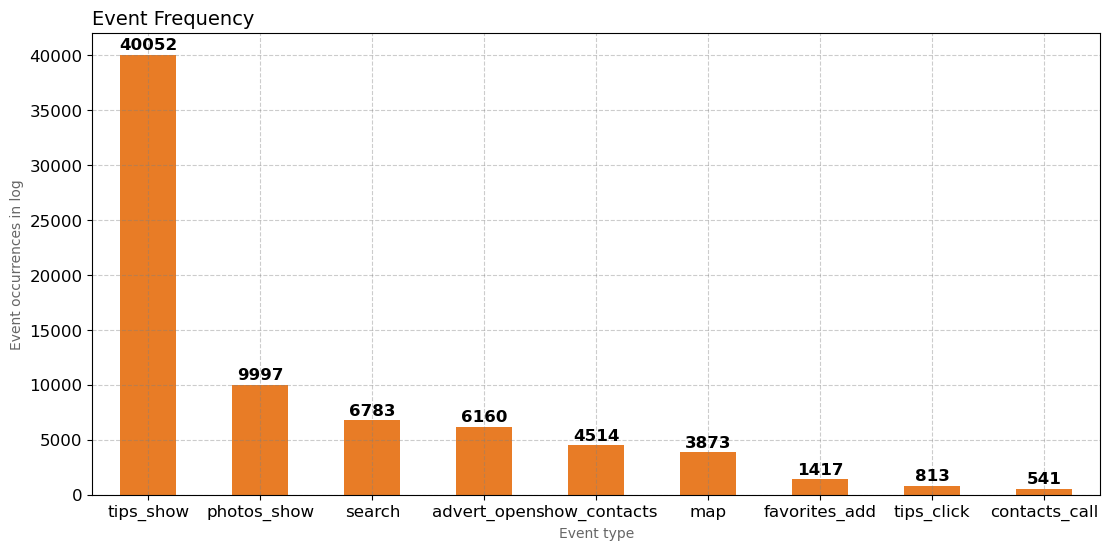

In [21]:
# Plot event frequency
ax = event_counts.plot(kind='bar', figsize=(13, 6), rot=0,
                       legend=False, fontsize=12, color='#E87C26')
plt.title('Event Frequency', fontsize=14, loc='left')
plt.xlabel('Event type', alpha=0.6)
plt.ylabel('Event occurrences in log', alpha=0.6)
plt.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.4)

# Add numerical labels above the bars
for i in ax.patches:
    ax.text(i.get_x() + i.get_width() / 2,  # Bar center
            i.get_height() + 200,           # Slightly above the bar
            str(int(i.get_height())),       # Displayed value
            ha='center', va='bottom',       # Centered horizontally, bottom-aligned vertically
            fontsize=12, color='black', weight='bold')  # Font size and color settings

plt.show()


The most frequent event is `tips_show` with the highest number of occurrences (40,052), followed by `photos_show` (9,997) and `search` (6,783). The least frequent events are `tips_click` (813) and `contacts_call` (541).


Now, let's count how many users performed each of these events. We'll sort the events by the number of unique users.


In [22]:
user_counts = df.groupby('event_name').agg({'user_id': 'nunique'}
                                          ).sort_values(by='user_id', ascending=False)
user_counts

,user_id
event_name,
tips_show,2801
search,1666
map,1456
photos_show,1095
show_contacts,981
advert_open,751
favorites_add,351
tips_click,322
contacts_call,213


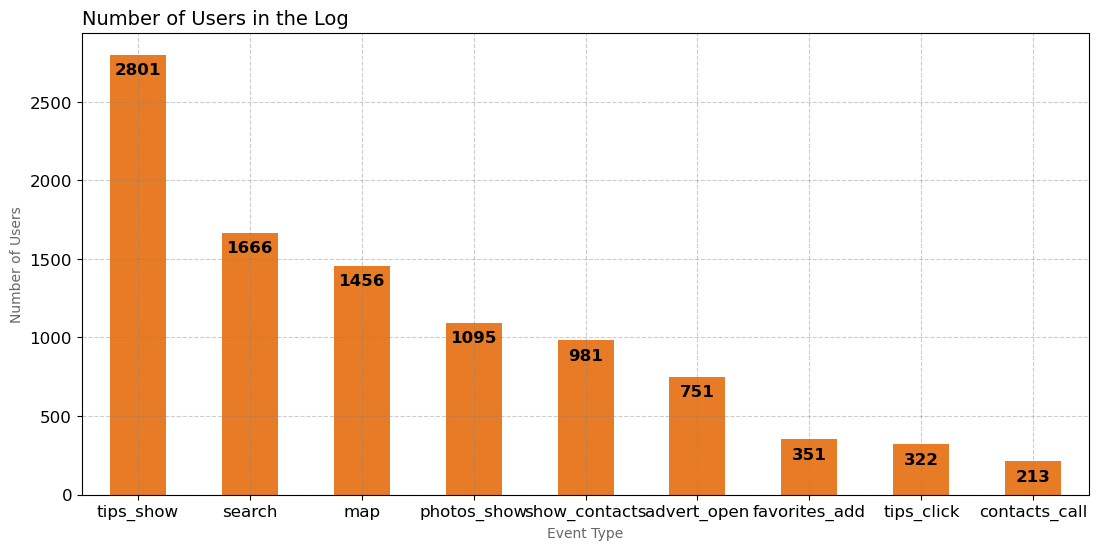

In [24]:
bx = user_counts['user_id'].plot(kind='bar', figsize=(13, 6), rot=0, 
                                 legend=False, fontsize=12, color='#E87C26')

plt.title('Number of Users in the Log', fontsize=14, loc='left')
plt.xlabel('Event Type', alpha=0.6)
plt.ylabel('Number of Users', alpha=0.6)
plt.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.4)

# Add values inside the bars
for i in bx.patches:
    bx.text(i.get_x() + i.get_width() / 2,  # Center of the bar
            i.get_height() - 50,            # Slightly below the top inside the bar
            str(int(i.get_height())),       # Value to display
            ha='center', va='top',          # Center text horizontally, align at the top
            fontsize=12, color='black', weight='bold')  # Font settings

plt.show()


The highest number of users was recorded for the `tips_show` event — 2801 users.  
Next in frequency: `search` (1666), `map` (1456), `photos_show` (1095), and `show_contacts` (981).  
The events with the fewest users: `advert_open` (751), `favorites_add` (351), `tips_click` (322), and `contacts_call` (213).


#### Identify the distribution of events over time (`event_time`)

In [25]:
# Determine the minimum and maximum event dates
print('First event date:', df['event_time'].min())
print('Last event date:', df['event_time'].max())


First event date: 2019-10-07 00:00:00.431000
Last event date: 2019-11-03 23:58:12.532000


We have data from October 7 to November 3, 2019.


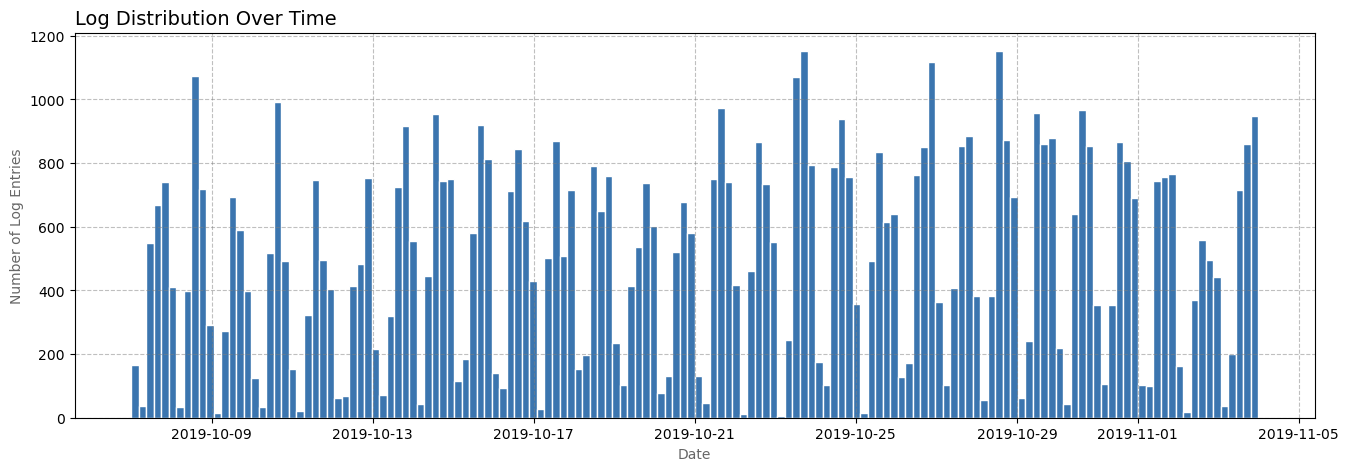

In [26]:
# Visualize how the amount of data changes over time
df['event_time'].hist(bins=150, figsize=(16, 5), color='#3b75af',
                      edgecolor='white')

plt.title('Log Distribution Over Time', fontsize=14, loc='left')
plt.xlabel('Date', alpha=0.6)
plt.ylabel('Number of Log Entries', alpha=0.6)
plt.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.5)
plt.show()


User activity varies, with peaks reaching around 1,000 log entries per day.  
Higher activity levels are observed in the middle and toward the end of the time period.

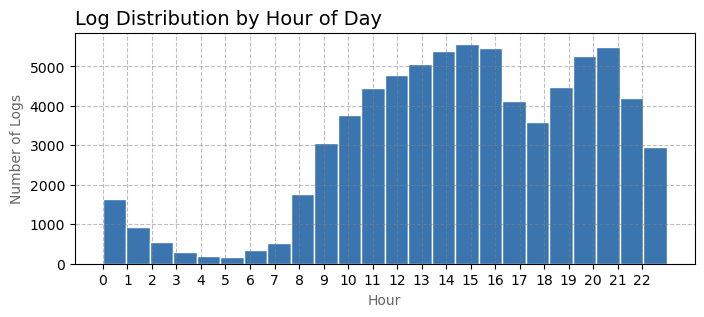

In [30]:
# User activity by hour of the day
df['event_time'].dt.hour.hist(bins=24, figsize=(8, 3), color='#3b75af',
                              edgecolor='white')
plt.title('Log Distribution by Hour of Day', fontsize=14, loc='left')
plt.xlabel('Hour', alpha=0.6)
plt.ylabel('Number of Logs', alpha=0.6)
plt.xticks(range(0, 23))
plt.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.5)
plt.show()


The highest user activity occurs between 12:00 and 21:00, peaking around 15:00.  
A slight drop is observed between 16:00 and 19:00.  
The lowest activity falls between 2:00 and 6:00 at night.

### Metric Analysis:

#### Retention Rate:

- Identify the date of the first event for each user.
- Create cohorts (by day or by week).
- Calculate the retention rate.
- Build a retention table.
- Visualize the results (heatmap).


In [31]:
# Identify the date of the first event for each user
first_event = df.groupby('user_id')['event_time'].min().reset_index()
first_event.columns = ['user_id', 'first_event']

# Merge the tables on user_id
df = df.merge(first_event, on='user_id', how='left')


In [32]:
# Create cohorts (by day)
df['cohort'] = df['first_event'].dt.date
df

,event_time,event_name,user_id,source,first_event,cohort
0,2019-10-07 00:00:00.431,advert_open,020292ab-89bc-4156-9acf-68bc2783f894,other,2019-10-07 00:00:00.431,2019-10-07
1,2019-10-07 00:00:01.236,tips_show,020292ab-89bc-4156-9acf-68bc2783f894,other,2019-10-07 00:00:00.431,2019-10-07
2,2019-10-07 00:00:02.245,tips_show,cf7eda61-9349-469f-ac27-e5b6f5ec475c,yandex,2019-10-07 00:00:02.245,2019-10-07
3,2019-10-07 00:00:07.039,tips_show,020292ab-89bc-4156-9acf-68bc2783f894,other,2019-10-07 00:00:00.431,2019-10-07
4,2019-10-07 00:00:56.320,advert_open,cf7eda61-9349-469f-ac27-e5b6f5ec475c,yandex,2019-10-07 00:00:02.245,2019-10-07
...,...,...,...,...,...,...
74145,2019-11-03 23:53:29.535,tips_show,28fccdf4-7b9e-42f5-bc73-439a265f20e9,google,2019-10-16 08:06:53.961,2019-10-16
74146,2019-11-03 23:54:00.407,tips_show,28fccdf4-7b9e-42f5-bc73-439a265f20e9,google,2019-10-16 08:06:53.961,2019-10-16
74147,2019-11-03 23:56:57.042,search,20850c8f-4135-4059-b13b-198d3ac59902,google,2019-10-27 19:19:01.979,2019-10-27
74148,2019-11-03 23:57:06.232,tips_show,28fccdf4-7b9e-42f5-bc73-439a265f20e9,google,2019-10-16 08:06:53.961,2019-10-16


In [33]:
# Define a function to calculate retention
def calculate_retention(df):
    """
    Calculates the Retention Rate based on user session data.

    Parameters:
    df - DataFrame containing the following columns:
        - cohort: the date of the user's first event (cohort)
        - event_time: timestamp of the event
        - first_event: timestamp of the user's first event
        - user_id: user identifier

    Returns:
    retention_pivot - a pivot table showing retention by cohort and user lifetime (days)
    """
    # Create a column for the number of days since the user's first event
    df['days_since_first_event'] = (df['event_time'] - df['first_event']).dt.days

    # Group by cohort and user lifetime
    retention = (
        df.groupby(['cohort', 'days_since_first_event'])
        .agg(users=('user_id', 'nunique'))
        .reset_index()
    )

    # Calculate cohort sizes (day 0)
    cohort_sizes = (
        retention[retention['days_since_first_event'] == 0]
        [['cohort', 'users']]
        .rename(columns={'users': 'cohort_size'})
    )

    # Merge with the main retention data
    retention = retention.merge(cohort_sizes, on='cohort')

    # Calculate retention rate
    retention['retention_rate'] = retention['users'] / retention['cohort_size']

    # Convert to pivot table format
    retention_pivot = retention.pivot(
        index='cohort', 
        columns='days_since_first_event', 
        values='retention_rate'
    )
    
    return retention_pivot


In [34]:
# Applying the function
retention_pivot = calculate_retention(df)
retention_pivot

days_since_first_event,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
cohort,,,,,,,,,,,,,,,,,,,,,
2019-10-07,1.0,0.122549,0.098039,0.107843,0.053922,0.039216,0.058824,0.078431,0.053922,0.049020,...,0.019608,0.044118,0.024510,0.014706,0.019608,0.034314,0.034314,0.039216,0.044118,0.029412
2019-10-08,1.0,0.161677,0.125749,0.053892,0.041916,0.065868,0.053892,0.071856,0.059880,0.041916,...,0.029940,0.017964,0.047904,0.035928,0.017964,0.023952,0.041916,0.029940,0.023952,0.011976
2019-10-09,1.0,0.073864,0.062500,0.056818,0.068182,0.068182,0.056818,0.073864,0.062500,0.034091,...,0.017045,0.011364,0.028409,0.011364,0.034091,0.011364,0.005682,0.022727,0.017045,NaN
2019-10-10,1.0,0.091954,0.103448,0.080460,0.097701,0.080460,0.068966,0.051724,0.080460,0.034483,...,0.063218,0.034483,0.028736,0.017241,0.040230,0.017241,0.011494,0.011494,NaN,NaN
2019-10-11,1.0,0.088235,0.117647,0.095588,0.088235,0.073529,0.073529,0.044118,0.014706,0.044118,...,0.058824,0.029412,0.022059,0.022059,0.029412,0.029412,0.014706,NaN,NaN,NaN
2019-10-12,1.0,0.128000,0.160000,0.056000,0.064000,0.088000,0.080000,0.088000,0.080000,0.064000,...,0.040000,0.040000,0.024000,0.024000,0.064000,0.032000,NaN,NaN,NaN,NaN
2019-10-13,1.0,0.128378,0.067568,0.054054,0.067568,0.054054,0.054054,0.047297,0.047297,0.047297,...,0.013514,0.020270,0.013514,0.033784,0.006757,NaN,NaN,NaN,NaN,NaN
2019-10-14,1.0,0.113514,0.102703,0.102703,0.081081,0.070270,0.054054,0.043243,0.075676,0.037838,...,0.037838,0.021622,0.016216,0.005405,NaN,NaN,NaN,NaN,NaN,NaN
2019-10-15,1.0,0.139785,0.091398,0.080645,0.053763,0.053763,0.080645,0.075269,0.064516,0.021505,...,0.032258,0.026882,0.016129,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Function to visualize retention
def plot_retention_heatmap(retention_pivot, exclude_first_day=True, horizon_days=None, title='Retention Heatmap'):
    """
    Plots a retention heatmap based on the retention_pivot DataFrame.

    Parameters:
    retention_pivot : DataFrame
        A pivot table with cohorts as the index and user lifetime (in days) as columns.
    exclude_first_day : bool, optional (default=True)
        Whether to exclude day 0 (first day of lifetime) from the heatmap.
    horizon_days : int, optional
        Retention horizon in days. If None, all available columns are used.
    title : str, optional (default='Retention Heatmap')
        Title of the plot.
    """

    # Create a custom color palette
    custom_cmap = LinearSegmentedColormap.from_list(
        'custom_cmap', ['#4A90E2', '#D3D3D3', '#E87C26'], N=256
    )
    
    plt.figure(figsize=(22, 9))
    
    # Drop day 0 if exclude_first_day is True
    if exclude_first_day:
        retention_pivot = retention_pivot.drop(columns=[0], errors='ignore')
    
    # Apply retention horizon if horizon_days is specified
    if horizon_days:
        retention_pivot = retention_pivot.iloc[:, :horizon_days]

    sns.heatmap(
        retention_pivot,    # data for the heatmap
        annot=True,         # show annotation labels
        fmt='.2%',          # format values as percentages
        cmap=custom_cmap,   # custom color scheme
        linewidths=0.5      # grid lines between cells
    )
    
    plt.title(title, loc='left')              # Plot title
    plt.xlabel('Lifetime (days)')             # X-axis label
    plt.ylabel('Cohort (start date)')         # Y-axis label
    plt.show()


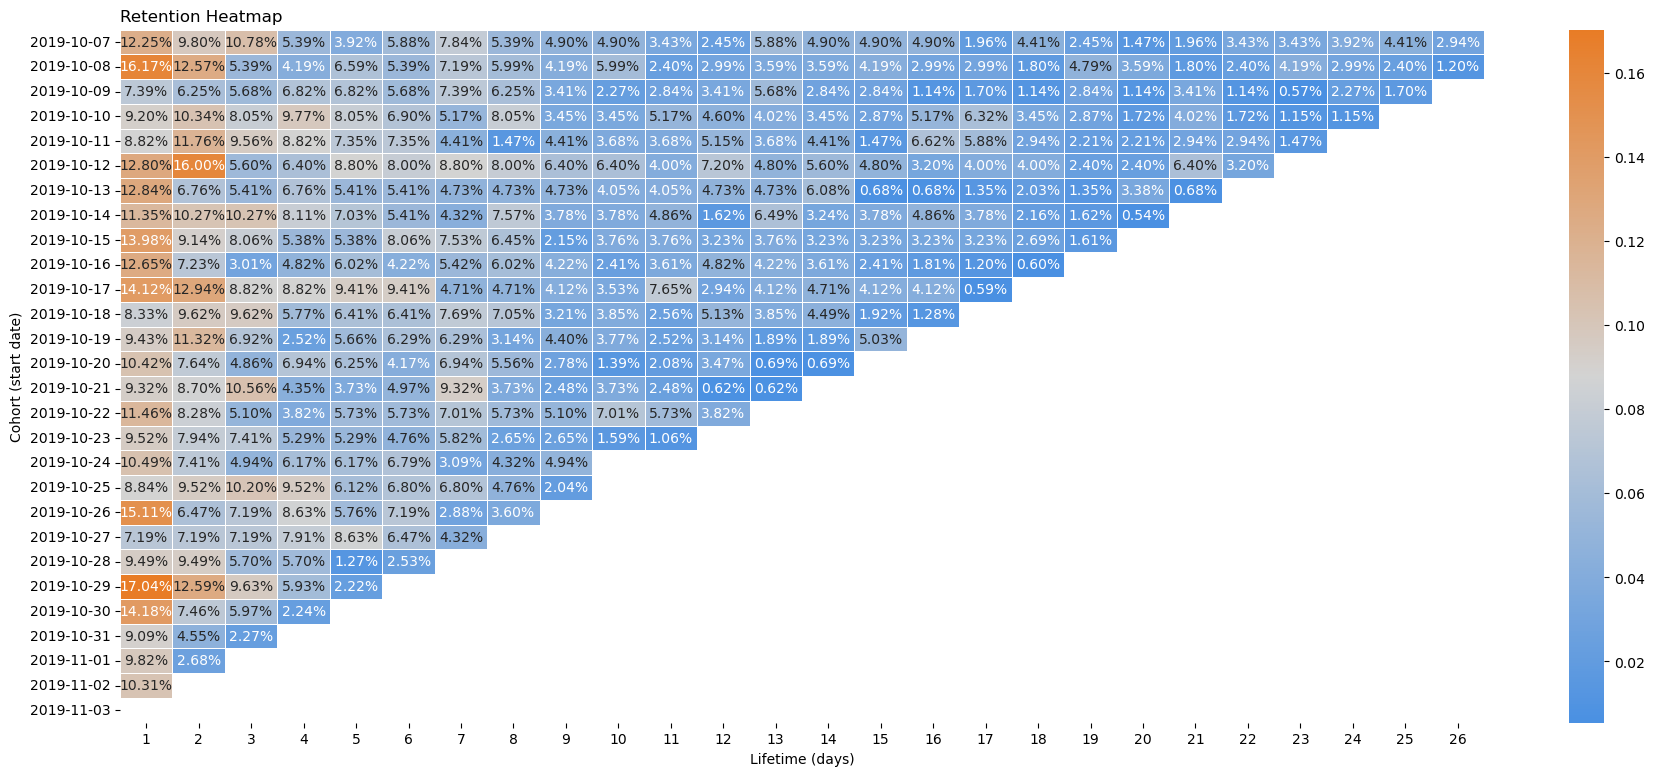

In [36]:
# plot heatmap excluding day 0 (first day of lifetime)
plot_retention_heatmap(retention_pivot)

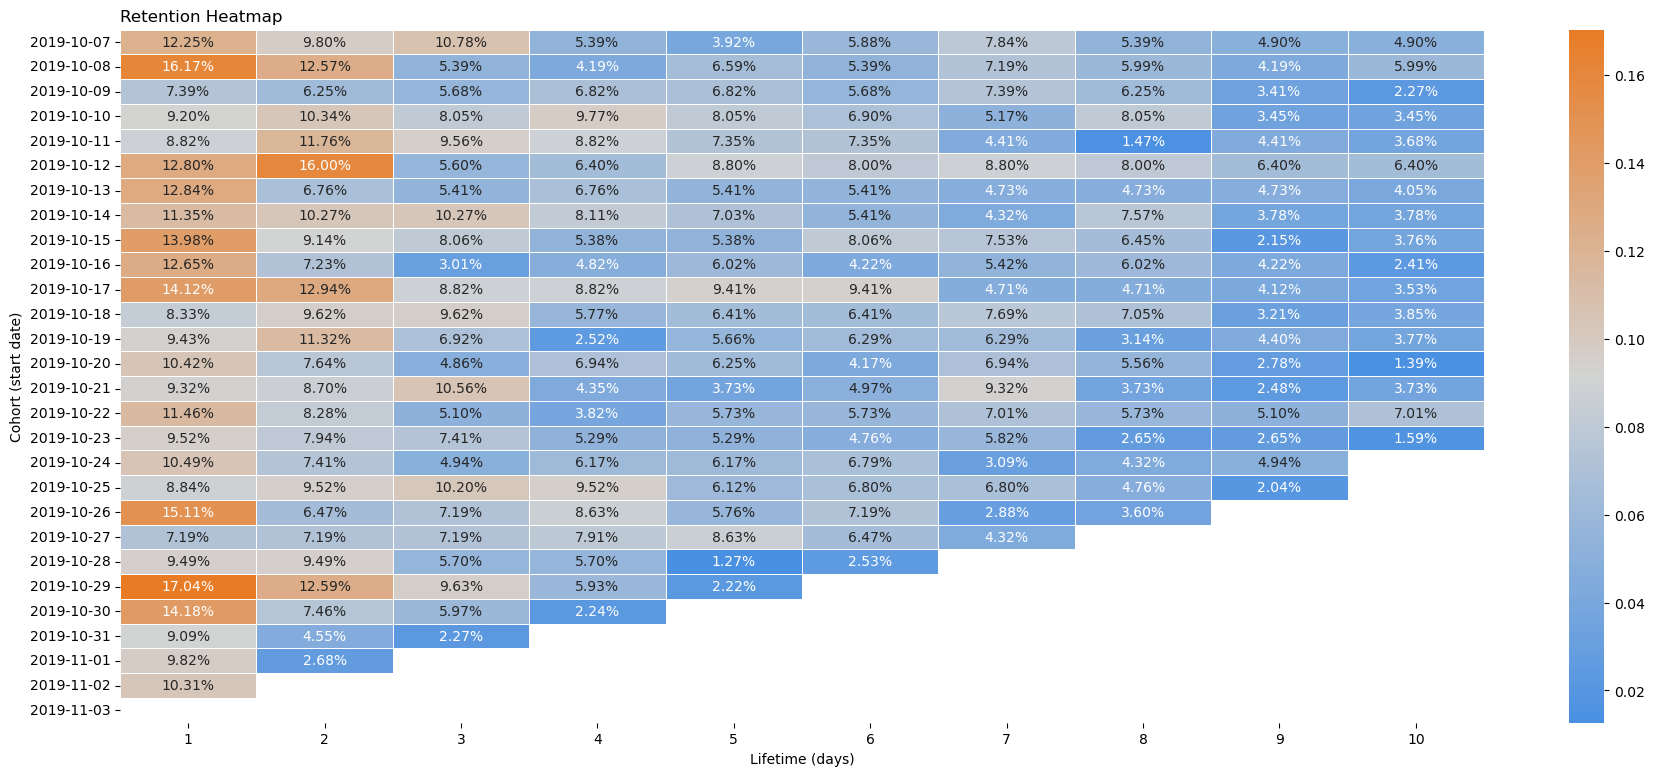

In [37]:
# plot heatmap with a 10-day analysis horizon
plot_retention_heatmap(retention_pivot, horizon_days=10)




- On day 2, only 12–16% of users return, and by day 5, retention drops to 5–8%.

- Some cohorts show higher initial retention (e.g., cohort **2019-10-08** with 16.2% and **2019-10-29** with 17% on day 1) or more prolonged engagement (e.g., cohort **2019-10-12** with 16.2% on day 1), compared to others. This may be related to different marketing campaigns, user acquisition sources, or other factors influencing behavior.

- After 7–8 days, retention stabilizes at around 2–4%, indicating that most users either stop using the app or engage with it only occasionally.

- Some anomalies are observed in certain cohort-day combinations, such as an increase in retention at later stages (e.g., **2019-10-26** cohort on day 7 with 8.6%). This could be due to reactivation efforts through reminders, promotions, or app updates.

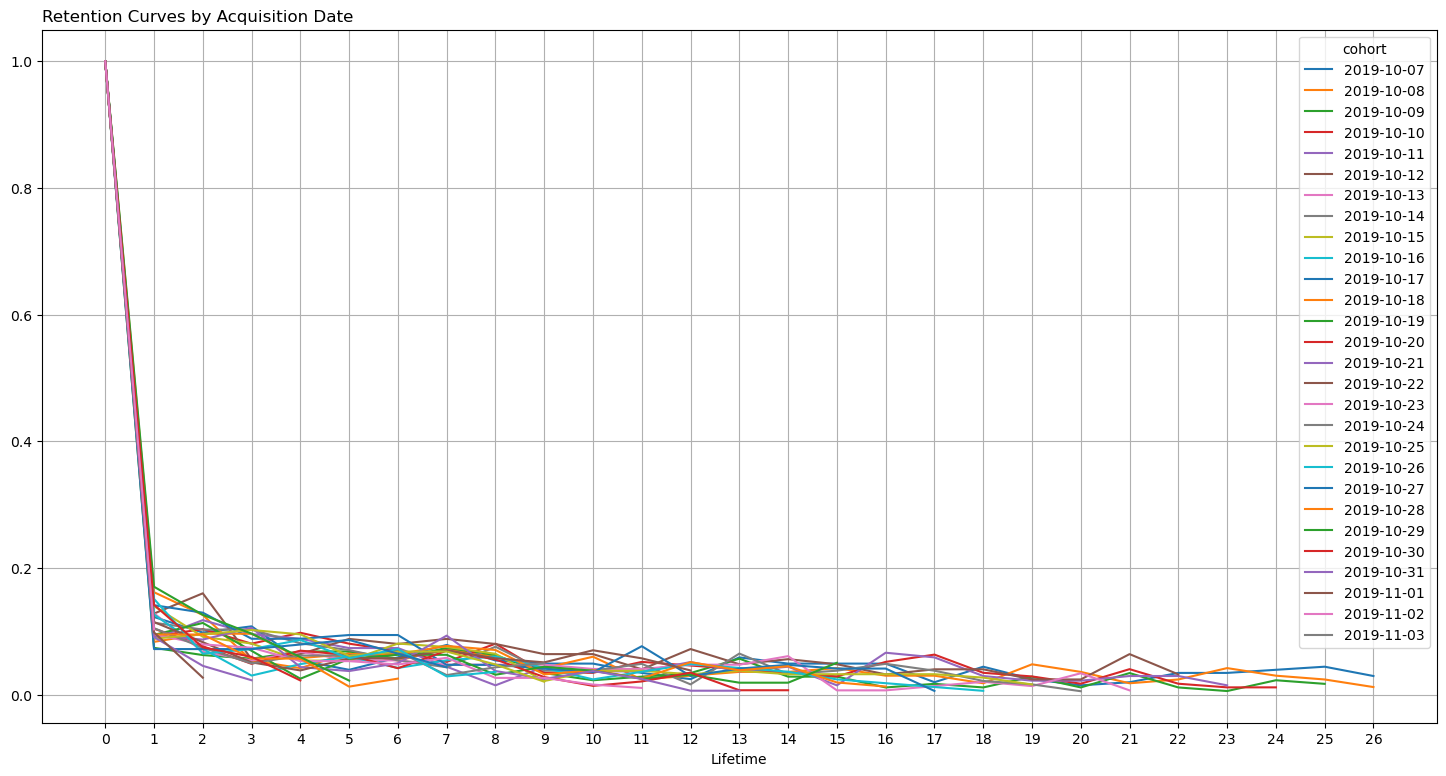

In [40]:
# plot retention curves
retention_pivot.T.plot(
    grid=True,  # add grid
    xticks=list(retention_pivot.columns.values),  # X-axis ticks — column names (days)
    figsize=(18, 9),  # figure size
)
plt.xlabel('Lifetime')  # X-axis label
plt.title('Retention Curves by Acquisition Date', loc='left')
plt.show()




User retention drops sharply on the first day, then declines more gradually. Some cohorts show temporary spikes in retention, possibly due to promotions or reminders. User behavior across cohorts becomes more similar in the later stages.

Let's examine how retention changes from cohort to cohort for each day of the user lifetime.

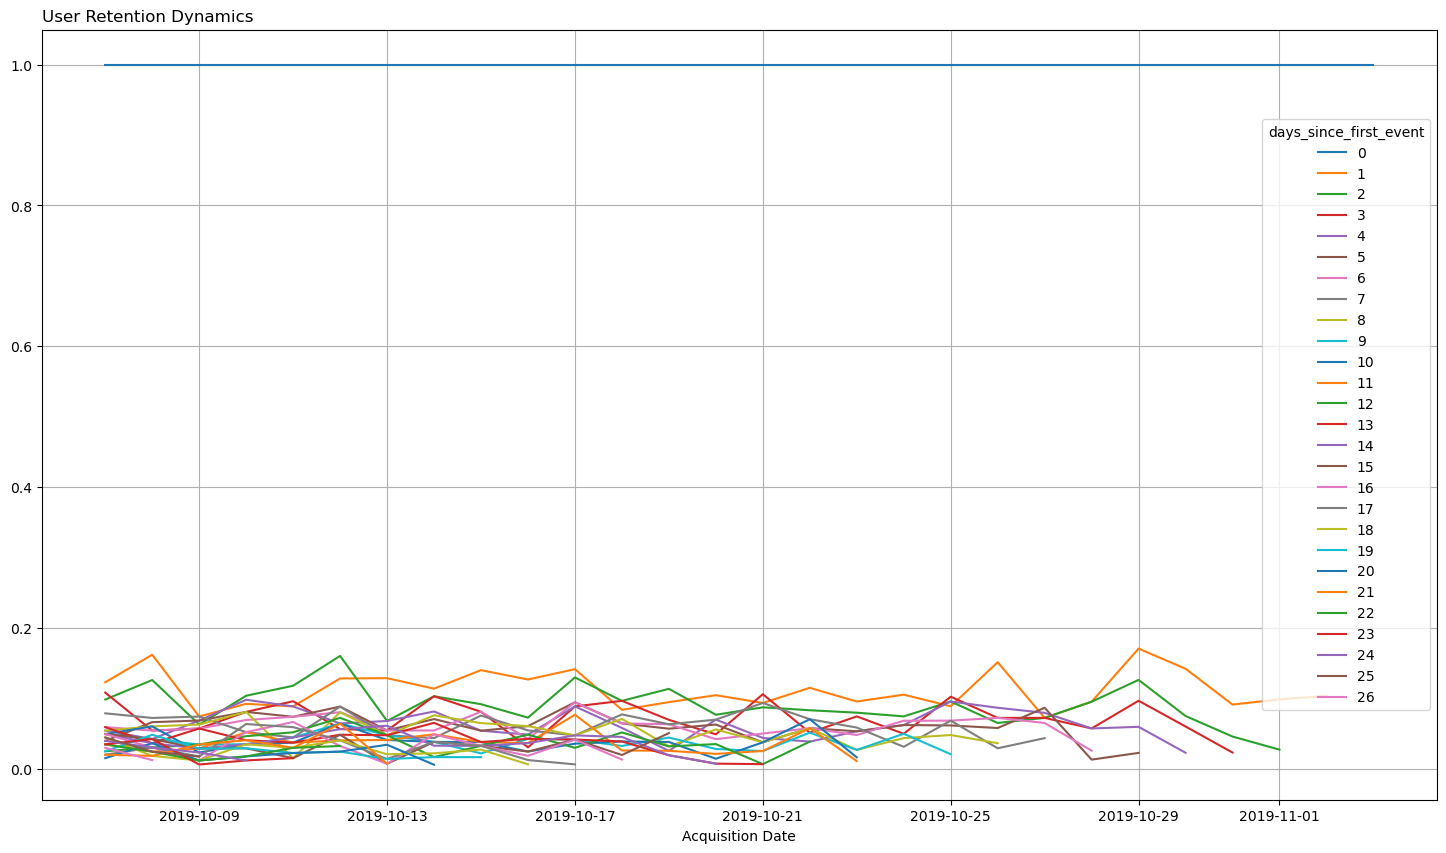

In [41]:
# plot retention dynamics
retention_pivot.plot(grid=True, figsize=(18, 10))
plt.xlabel('Acquisition Date')
plt.title('User Retention Dynamics', loc='left')
plt.show()


The chart shows a significant gap between the first day and all subsequent days.  
Fluctuations in retention are noticeable for certain days, which may be related to promotional activities or external factors.  
After day 5, retention becomes more stable at a low level.

**Conclusion:**  
The overall trend: retention drops sharply after the first day (only 12–16% of users return),  
and remains low and stable afterward.


#### Time Spent in the App:
##### Split user events into sessions (30-minute window)

Why is 30 minutes a good choice for this app?

A 30-minute timeout is a standard solution suitable for most users, especially when browsing or searching for items.  
User behavior in this case is similar to e-commerce platforms, where sessions are typically divided as follows:  
search → contact the seller (purchase) → exit the app.  
If a user is inactive for 30 minutes, it most likely means they have finished searching or got distracted.

If the user decides to return to the app later, it is considered a new session of searching and comparing.  
The 30-minute timeout helps avoid merging unrelated periods of activity.


In [42]:
# Sort the DataFrame by user_id and event time
df = df.sort_values(['user_id', 'event_time'])

# Group by user_id and calculate the time difference from the previous event
df['diff_prev'] = (
    df
    .groupby('user_id')['event_time']
    .diff()
    .dt.total_seconds()
    .div(60)  # convert seconds to minutes
)

# Define session timeout threshold
time_out = 30

# New session flag: either diff_prev == NaN (first event for user),
# or diff_prev > 30 minutes
new_session = (df['diff_prev'].isna()) | (df['diff_prev'] > time_out)

# Create session_id column to separate events into sessions
df['session_id'] = new_session.cumsum()


##### Count the sessions of each user

In [43]:
# Count sessions for each user
sessions_per_user = (
    df
    .groupby('user_id')['session_id']
    .nunique()  # count unique sessions
    .reset_index(name='sessions_count')
)

sessions_per_user


,user_id,sessions_count
0,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,4
1,00157779-810c-4498-9e05-a1e9e3cedf93,6
2,00463033-5717-4bf1-91b4-09183923b9df,1
3,004690c3-5a84-4bb7-a8af-e0c8f8fca64e,6
4,00551e79-152e-4441-9cf7-565d7eb04090,3
...,...,...
4288,ffab8d8a-30bb-424a-a3ab-0b63ebbf7b07,2
4289,ffc01466-fdb1-4460-ae94-e800f52eb136,1
4290,ffcf50d9-293c-4254-8243-4890b030b238,1
4291,ffe68f10-e48e-470e-be9b-eeb93128ff1a,3


In [44]:
# Adding a table of users by user_id (it will be useful in the future)
df = df.merge(sessions_per_user, on='user_id', how='left')

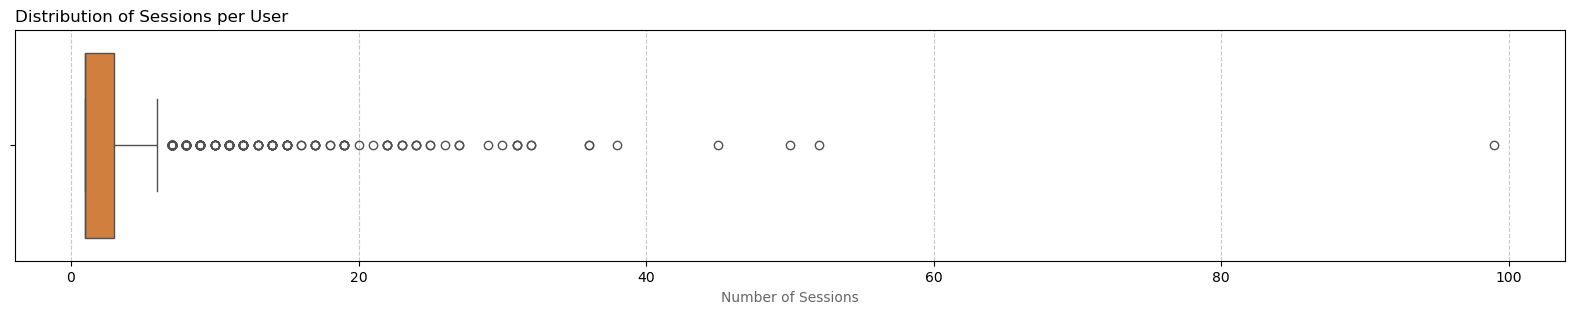

In [45]:
# Plot boxplot
plt.figure(figsize=(20, 3))
sns.boxplot(data=sessions_per_user, x='sessions_count', color='#E87C26')
plt.title('Distribution of Sessions per User', loc='left')
plt.xlabel('Number of Sessions', alpha=0.6)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


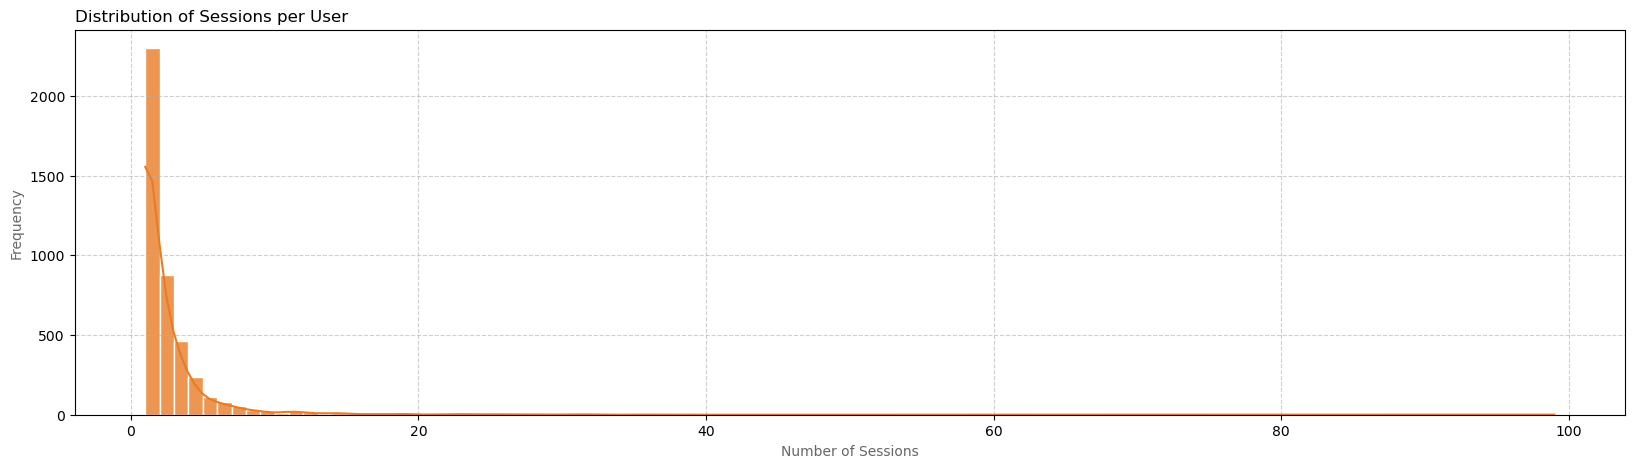

In [46]:
# Histogram
plt.figure(figsize=(20, 5))
sns.histplot(data=sessions_per_user, x='sessions_count', kde=True, color='#E87C26',
             binwidth=1, bins=100, alpha=0.8, edgecolor='white')
plt.title('Distribution of Sessions per User', loc='left')
plt.xlabel('Number of Sessions', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


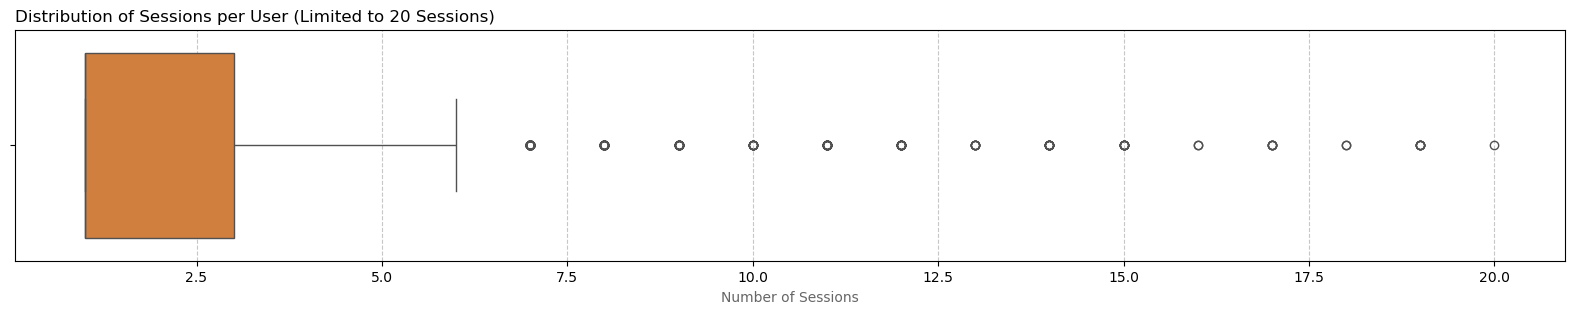

In [47]:
# Limit the number of sessions per user to a maximum of 20
sessions_per_user_limited = sessions_per_user[sessions_per_user['sessions_count'] <= 20]

# Plot boxplot
plt.figure(figsize=(20, 3))
sns.boxplot(data=sessions_per_user_limited, x='sessions_count', color='#E87C26')
plt.title('Distribution of Sessions per User (Limited to 20 Sessions)', loc='left')
plt.xlabel('Number of Sessions', alpha=0.6)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


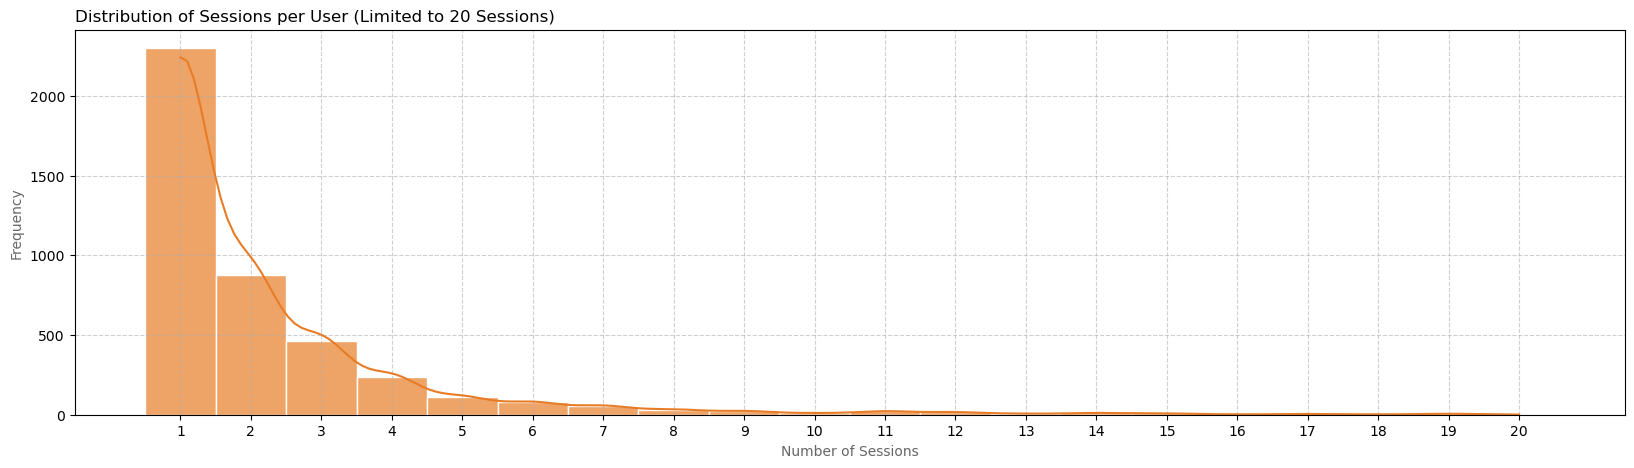

In [48]:
# Histogram
plt.figure(figsize=(20, 5))
bins = np.arange(0.5, 20.6, 1)

sns.histplot(
    data=sessions_per_user_limited, 
    x='sessions_count', 
    bins=bins, 
    kde=True,
    edgecolor='white', 
    color='#E87C26',
    alpha=0.7
)

plt.xticks(range(1, 21))

plt.title('Distribution of Sessions per User (Limited to 20 Sessions)', loc='left')
plt.xlabel('Number of Sessions', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [49]:
# Distribution of session counts
sessions_per_user['sessions_count'].describe().to_frame()

,sessions_count
count,4293.000000
mean,2.415094
std,3.536466
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,99.000000


In [50]:
# How many users had only one session
print(f'Users with 1 session: {sessions_per_user[sessions_per_user["sessions_count"] == 1].shape[0]}')

Users with 1 session: 2300




**Conclusion**:

- The majority of users (around 53%) completed only one session.

- The median is also 1, and the upper quartile is 3. Most of the sample falls within the range of 1 to 3 sessions.

- The maximum value (99 sessions) and several other high values indicate the presence of "super-active" users, forming a long right tail in the distribution.

- The histogram shows a peak at 1–2 sessions (most users), followed by a rapid decline in the number of users.

- Anything above 5–7 sessions is relatively rare.

- Thus, the distribution of sessions per user is heavily right-skewed: most users complete only a small number of sessions, while a few exhibit very high activity.

##### Calculate session duration


In [51]:
# Group by user and session, and get minimum/maximum timestamps
session_times = (
    df
    .groupby(['user_id', 'session_id'], as_index=False)
    .agg(session_start=('event_time', 'min'),
         session_end=('event_time', 'max'))
)

# Calculate the time difference between session_end and session_start
session_times['session_duration'] = (
    session_times['session_end'] - session_times['session_start']
).dt.total_seconds() / 60  # convert seconds to minutes

session_times.head()


,user_id,session_id,session_start,session_end,session_duration
0,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,1,2019-10-07 13:39:45.989,2019-10-07 13:49:41.717,9.928800
1,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,2,2019-10-09 18:33:55.578,2019-10-09 18:42:22.964,8.456433
2,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,3,2019-10-21 19:52:30.779,2019-10-21 20:07:30.051,14.987867
3,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,4,2019-10-22 11:18:14.635,2019-10-22 11:30:52.807,12.636200
4,00157779-810c-4498-9e05-a1e9e3cedf93,5,2019-10-19 21:34:33.850,2019-10-19 21:59:54.637,25.346450


##### Explore session duration distribution


In [52]:
# Session duration distribution
session_times['session_duration'].describe().to_frame()

,session_duration
count,10368.000000
mean,12.877877
std,19.860189
min,0.000000
25%,0.352287
50%,5.586167
75%,17.423192
max,321.971600


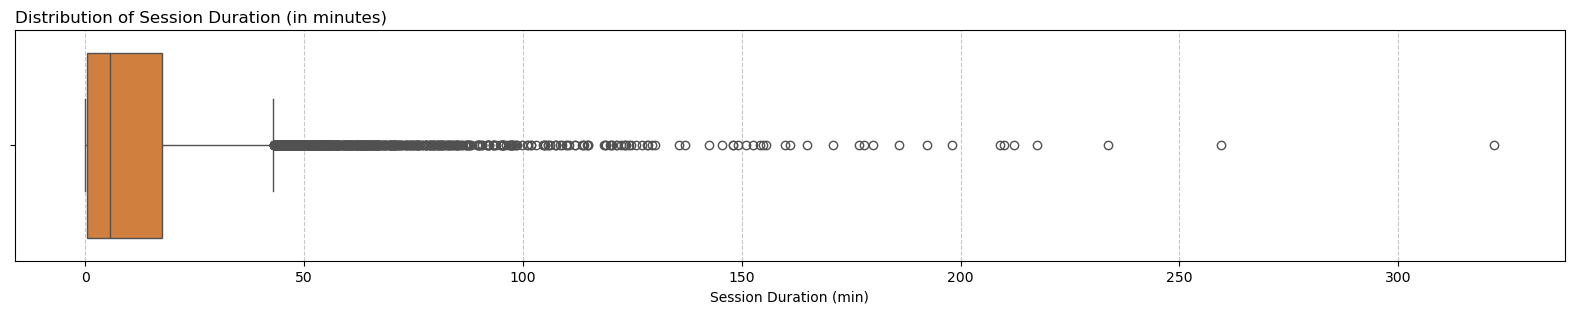

In [53]:
# Plot boxplot of session duration
plt.figure(figsize=(20, 3))
sns.boxplot(data=session_times, x='session_duration', color='#E87C26')
plt.title('Distribution of Session Duration (in minutes)', loc='left')
plt.xlabel('Session Duration (min)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


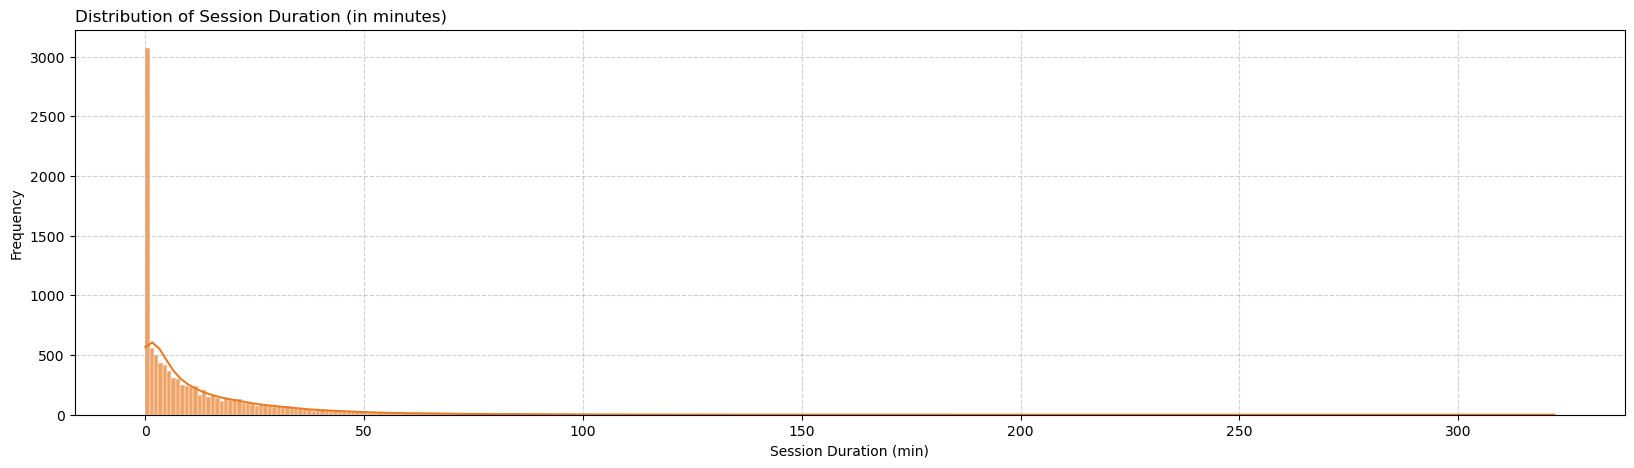

In [54]:
# Histogram of session duration
plt.figure(figsize=(20, 5))
sns.histplot(data=session_times, x='session_duration', kde=True, alpha=0.7,
             binwidth=1, bins=100, color='#E87C26', edgecolor='white')
plt.title('Distribution of Session Duration (in minutes)', loc='left')
plt.xlabel('Session Duration (min)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


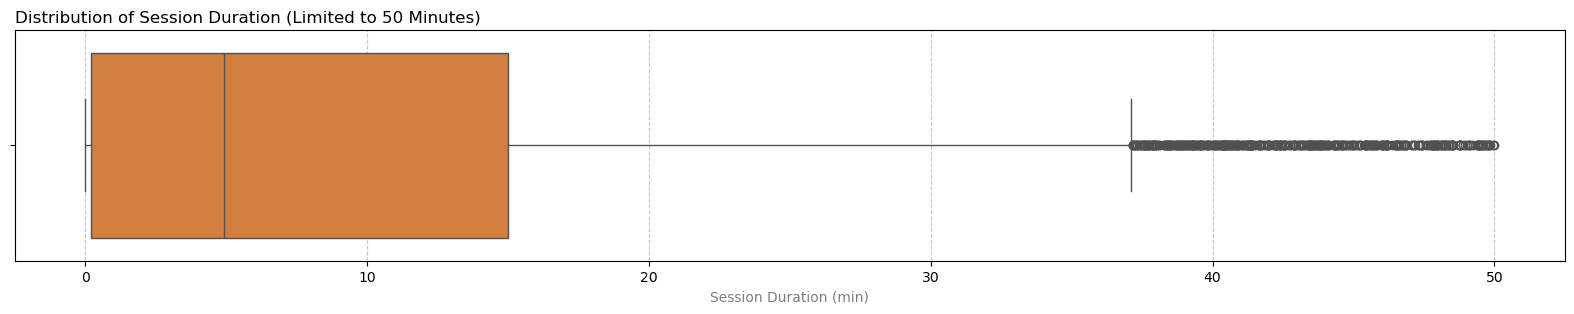

In [55]:
# Filter sessions with duration <= 50 minutes
filtered_sessions = session_times[session_times['session_duration'] <= 50]


# Boxplot for sessions up to 50 minutes
plt.figure(figsize=(20, 3))
sns.boxplot(data=filtered_sessions, x='session_duration', color='#E87C26')
plt.title('Distribution of Session Duration (Limited to 50 Minutes)', loc='left')
plt.xlabel('Session Duration (min)', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


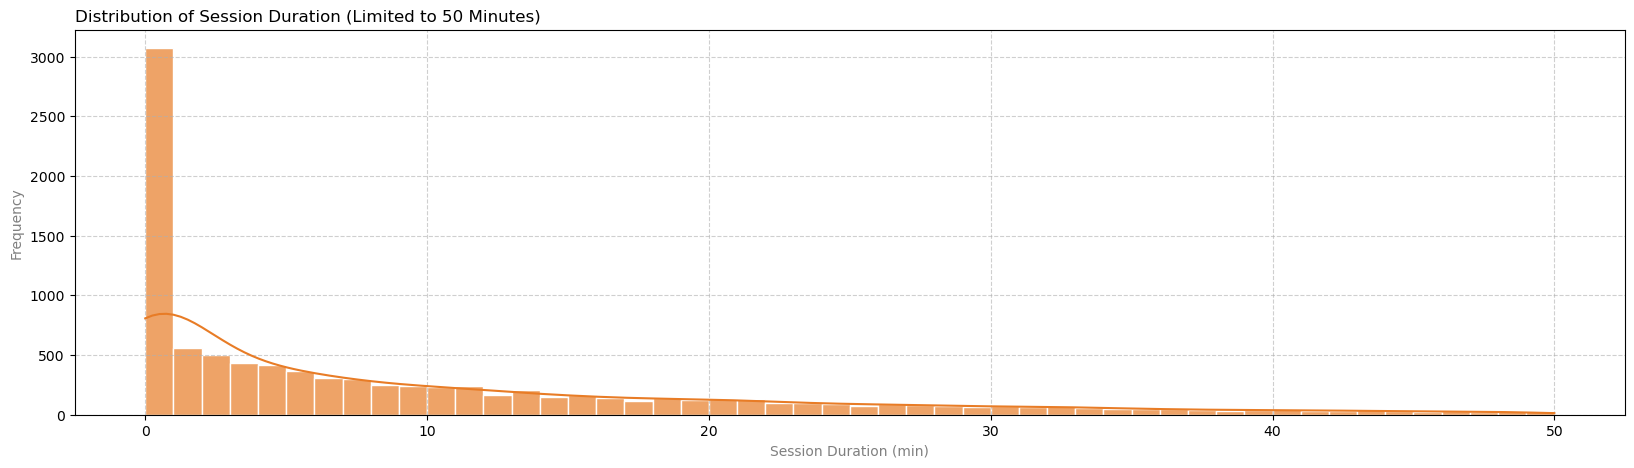

In [56]:
# Histogram for sessions up to 50 minutes
plt.figure(figsize=(20, 5))
sns.histplot(data=filtered_sessions, x='session_duration', kde=True,
             alpha=0.7, binwidth=1, bins=50, color='#E87C26', edgecolor='white')
plt.title('Distribution of Session Duration (Limited to 50 Minutes)', loc='left')
plt.xlabel('Session Duration (min)', alpha=0.5)
plt.ylabel('Frequency', alpha=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [58]:
# Analyze extremely short and long sessions

# Check sessions with zero duration
print(
    f'Sessions with zero duration: '
    f'{session_times.query("session_duration == 0").shape[0]}'
)

# Analyze very short sessions (less than 1 minute)
print(
    f'Sessions under 1 minute: '
    f'{session_times[session_times["session_duration"] < 1].shape[0]}'
)

# Analyze long sessions (above the 95th percentile)
long_threshold = session_times['session_duration'].quantile(0.95)
print(
    f'Long sessions (over {long_threshold:.2f} minutes): '
    f'{session_times[session_times["session_duration"] > long_threshold].shape[0]}'
)


Sessions with zero duration: 2089
Sessions under 1 minute: 3072
Long sessions (over 48.52 minutes): 519




**Conclusion:**  

- **Total number of sessions**: 10,368. Average session duration: **12.88 minutes**. Median: **5.59 minutes**. 75% of sessions are under **17.42 minutes**. Maximum session duration: **321.97 minutes**. Standard deviation: **19.86 minutes**, indicating a wide spread — presence of outliers and long sessions.

- **Many short sessions and outliers in the form of long sessions.**  
  **2,089 sessions (20%)** have a duration of zero — possibly due to immediate exits or logging errors.  
  **3,072 sessions (30%)** are shorter than 1 minute — indicating low engagement or testing behavior.  
  For deeper analysis, it's advisable to investigate the causes of zero-duration sessions and exclude them from further calculations.

- The **first session** is a key churn point.  
  Solving the problem of low engagement requires optimizing the user journey, analyzing technical issues, and collecting feedback from users who abandon the app too quickly.

- **519 sessions (5%)** are longer than **48.52 minutes** — likely outliers or forgotten tabs.  
  Long sessions (over 50 minutes) should be considered separately as anomalies.

##### Session Duration Distribution for Users with Only One Session


In [59]:
# Merge session_start, session_end, and session_duration into df
df = df.merge(
    session_times[['user_id', 'session_id', 'session_start', 'session_end', 'session_duration']], 
    on=['user_id', 'session_id'], 
    how='left'
)

# Check the result
df.head()


,event_time,event_name,user_id,source,first_event,cohort,days_since_first_event,diff_prev,session_id,sessions_count,session_start,session_end,session_duration
0,2019-10-07 13:39:45.989,tips_show,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,other,2019-10-07 13:39:45.989,2019-10-07,0,NaN,1,4,2019-10-07 13:39:45.989,2019-10-07 13:49:41.717,9.9288
1,2019-10-07 13:40:31.053,tips_show,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,other,2019-10-07 13:39:45.989,2019-10-07,0,0.751067,1,4,2019-10-07 13:39:45.989,2019-10-07 13:49:41.717,9.9288
2,2019-10-07 13:41:05.722,tips_show,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,other,2019-10-07 13:39:45.989,2019-10-07,0,0.577817,1,4,2019-10-07 13:39:45.989,2019-10-07 13:49:41.717,9.9288
3,2019-10-07 13:43:20.735,tips_show,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,other,2019-10-07 13:39:45.989,2019-10-07,0,2.250217,1,4,2019-10-07 13:39:45.989,2019-10-07 13:49:41.717,9.9288
4,2019-10-07 13:45:30.918,tips_show,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,other,2019-10-07 13:39:45.989,2019-10-07,0,2.169717,1,4,2019-10-07 13:39:45.989,2019-10-07 13:49:41.717,9.9288


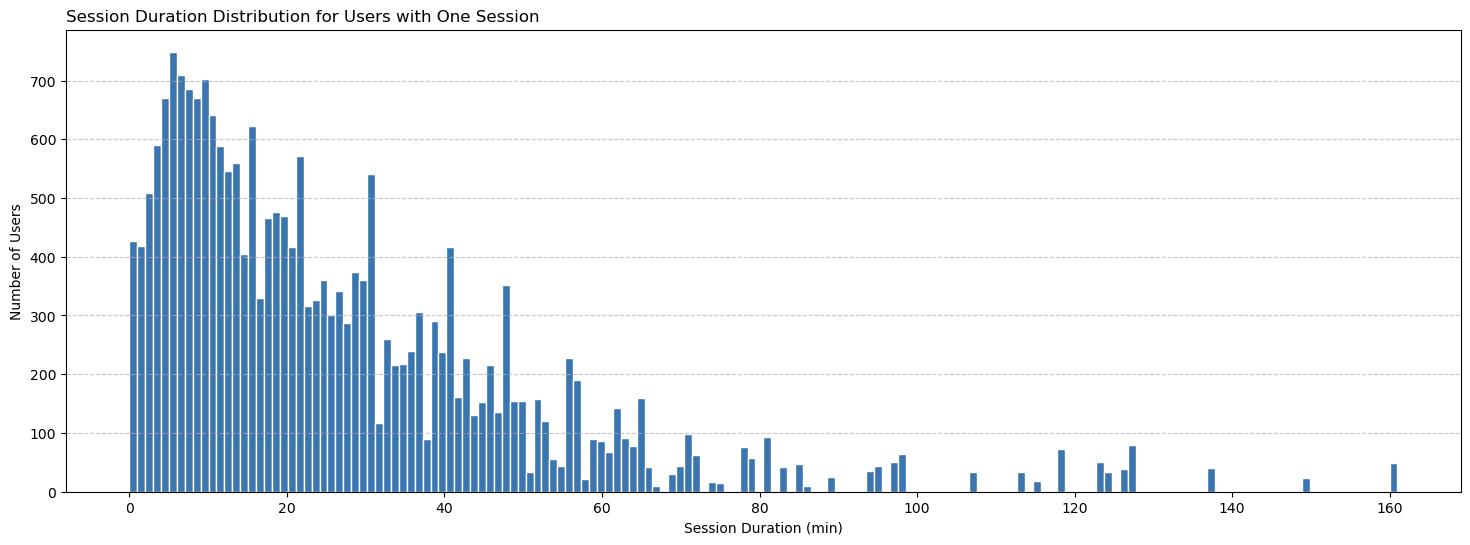

In [60]:
# 1. Filter users with only one session
one_session_users = df[df['sessions_count'] == 1]

# 2. Plot histogram of session_duration
plt.figure(figsize=(18, 6))
plt.hist(one_session_users['session_duration'].dropna(), bins=160, color='#3b75af', edgecolor='white')
plt.title('Session Duration Distribution for Users with One Session', loc='left')
plt.xlabel('Session Duration (min)')
plt.ylabel('Number of Users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [61]:
# Filter users with only one session and session_duration < 1 minute
short_sessions = one_session_users[one_session_users['session_duration'] < 1]

# Count unique users
unique_users = short_sessions['user_id'].nunique()

print(f"Number of users with one session and session_duration < 1 minute: {unique_users}")


Number of users with one session and session_duration < 1 minute: 158


**Conclusion**  
- Among users with only one session, 158 people (3.68%) ended their session in less than 1 minute.  
  This is a small proportion that may indicate technical or UX issues, or low engagement for some users.  
  However, it doesn't appear to be a major problem — otherwise, the share would be higher.


##### Calculate the average session duration for each user

In [62]:
user_avg_session = (
    session_times
    .groupby('user_id')['session_duration']
    .mean()
    .reset_index(name='avg_session_duration')
)

user_avg_session.head()


,user_id,avg_session_duration
0,0001b1d5-b74a-4cbf-aeb0-7df5947bf349,11.502325
1,00157779-810c-4498-9e05-a1e9e3cedf93,32.706133
2,00463033-5717-4bf1-91b4-09183923b9df,24.707917
3,004690c3-5a84-4bb7-a8af-e0c8f8fca64e,18.456553
4,00551e79-152e-4441-9cf7-565d7eb04090,3.109250


In [63]:
# View descriptive statistics
user_avg_session['avg_session_duration'].describe().to_frame()

,avg_session_duration
count,4293.000000
mean,14.258788
std,15.726131
min,0.000000
25%,3.978383
50%,9.376122
75%,19.155100
max,161.014867


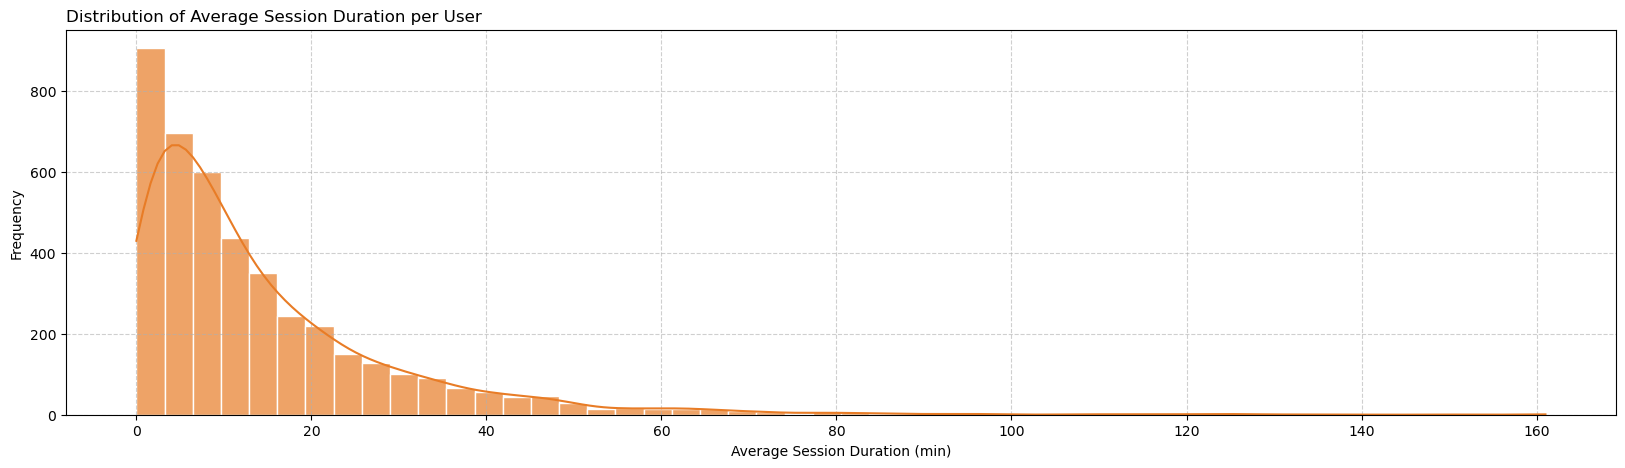

In [64]:
# Explore the distribution of average session duration per user

plt.figure(figsize=(20, 5))
sns.histplot(user_avg_session['avg_session_duration'], bins=50, kde=True,
             color="#E87C26", alpha=0.7, edgecolor='white')
plt.title('Distribution of Average Session Duration per User', loc='left')
plt.xlabel('Average Session Duration (min)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [65]:
# Users with an average session duration equal to 0
zero_session_users = user_avg_session[user_avg_session['avg_session_duration'] == 0]
print(
    f'Users with average session duration equal to 0: '
    f'{zero_session_users.shape[0]}'
)

# Users with an average session duration less than 1 minute
short_session_users = user_avg_session[user_avg_session['avg_session_duration'] < 1]
print(
    f'Users with average session duration under 1 minute: '
    f'{short_session_users.shape[0]}'
)

# Users with long sessions (above the 95th percentile)
long_threshold = user_avg_session['avg_session_duration'].quantile(0.95)
long_session_users = user_avg_session[user_avg_session['avg_session_duration'] > long_threshold]
print(
    f'Users with average session duration longer than {long_threshold:.2f} minutes: '
    f'{long_session_users.shape[0]}'
)


Users with average session duration equal to 0: 83
Users with average session duration under 1 minute: 360
Users with average session duration longer than 44.02 minutes: 215




**Conclusion:**

- **Total number of users**: 4,293. Average session duration per user: **14.26 minutes**. Median: **9.38 minutes**.  
  75% of users have an average session duration of **less than 19.16 minutes**.  
  Maximum average session duration: **161 minutes**.  
  Standard deviation: **15.73 minutes**, indicating a wide spread and the presence of users with unusually long sessions.

- **There is a group of users with extremely short sessions.**  
  83 users (about **2%**) have an average session duration of **0 minutes** — likely due to logging errors or instant exits.  
  360 users (about **8%**) have an average session duration **under 1 minute**, which may indicate low engagement or test accounts.

- **Long sessions (above the 95th percentile):**  
  215 users (about **5%**) have an average session duration **longer than 44.02 minutes**.  
  These users may represent outliers or heavy app usage.

In [66]:
# Counting the number of events for sessions with zero duration
event_distribution = df[df['session_duration'] == 0]['event_name'].value_counts()

event_distribution.to_frame()


,count
event_name,
tips_show,892
photos_show,513
search,377
show_contacts,124
map,98
advert_open,45
favorites_add,30
tips_click,10


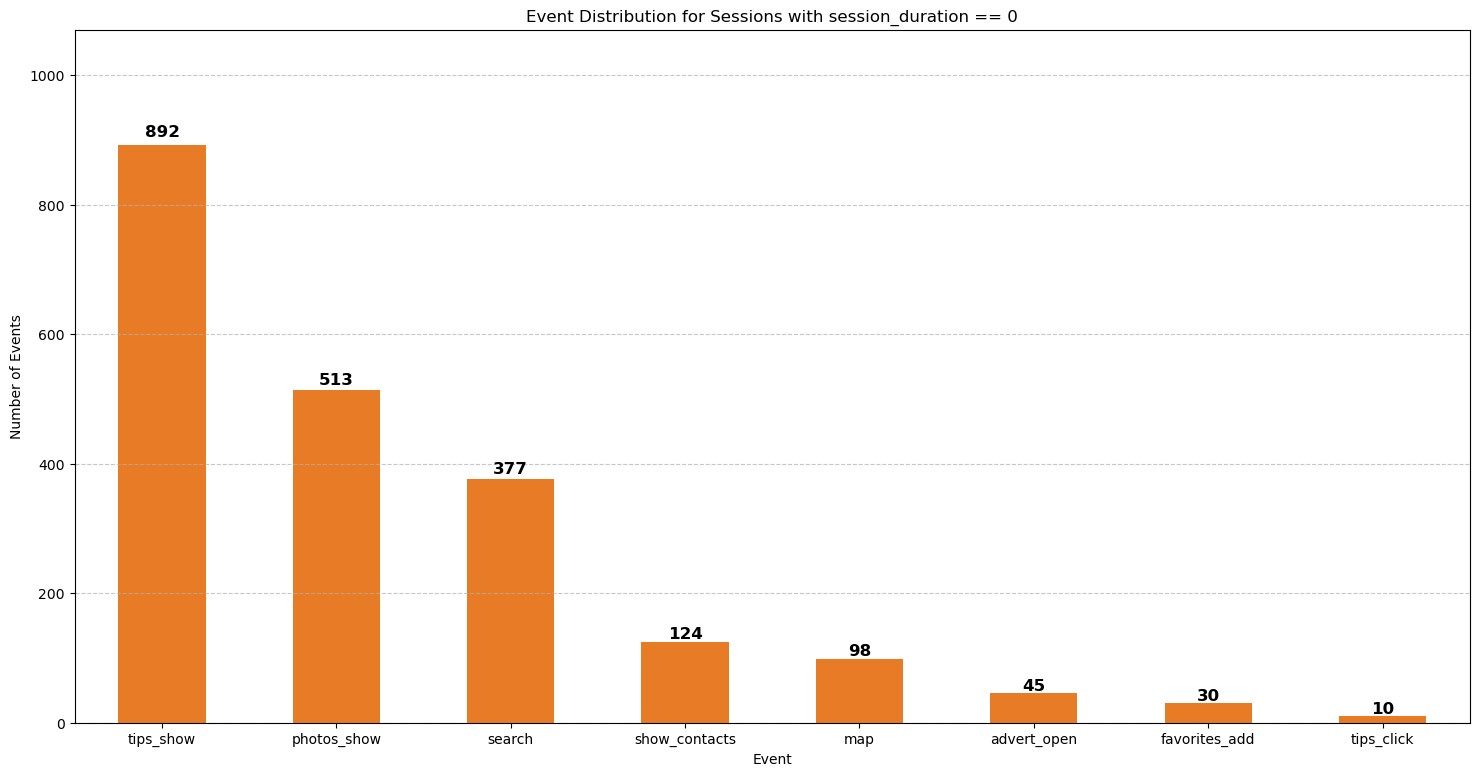

In [67]:
plt.figure(figsize=(18, 9))
ax = event_distribution.plot(kind='bar', color='#E87C26')  # Set bar color
plt.title('Event Distribution for Sessions with session_duration == 0')
plt.xlabel('Event')
plt.ylabel('Number of Events')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Automatically adjust text position
for i in ax.patches:
    ax.text(i.get_x() + i.get_width() / 2,
            i.get_height() + i.get_height() * 0.01,  
            str(int(i.get_height())),
            ha='center', va='bottom',
            fontsize=12, color='black', weight='bold')

# Set upper Y-axis limit for clarity
plt.ylim(0, event_distribution.max() * 1.2)

plt.show()


**Conclusion:**

The most frequent event is `tips_show` (892), which is likely the first event triggered upon entering the app (at the beginning of the user journey).  
This suggests that these are not system errors, but rather user behavior — users quickly opened and closed the app.

In general, zero-duration sessions with events like `photos_show`, `search`, `show_contacts`, `map`, and others appear to reflect scenarios where users previously paused at some stage of browsing, then reopened and quickly exited the app — possibly by accident.


#### Action Frequency:
- Calculate the average number of actions performed by a user.
- Plot the distribution of action counts.

- Calculate the number of events (by day and by day of the week).
- Visualize the number of events (by day and by weekday).


##### Distribution of the number of events

In [68]:
# Count the number of events for each user
events_per_user = df.groupby('user_id').size()

# Number of users who performed exactly one action
users_with_one_event = events_per_user[events_per_user == 1].shape[0]
print("Users who performed only 1 action:", users_with_one_event)


Users who performed only 1 action: 65


Let's look at the distribution of events for users with one session and zero duration.

In [69]:
# Filtering users with one session and session_duration == 0:
one_session_zero_duration = df[
    (df['sessions_count'] == 1) & (df['session_duration'] == 0)
]

# Counting the number of events:
event_distribution = one_session_zero_duration['event_name'].value_counts()
event_distribution.to_frame()

,count
event_name,
tips_show,30
map,16
search,8
show_contacts,6
photos_show,4
advert_open,1


In half of the cases, the event is `tips_show` — most likely the first event triggered upon entering the app.  
Others may have come via a link from somewhere else but quickly closed the app.  
There are very few such events overall, so this is likely a normal situation.


In [70]:
# View descriptive statistics
events_per_user.describe()

count    4293.000000
mean       17.272304
std        29.089254
min         1.000000
25%         5.000000
50%         9.000000
75%        17.000000
max       477.000000
dtype: float64

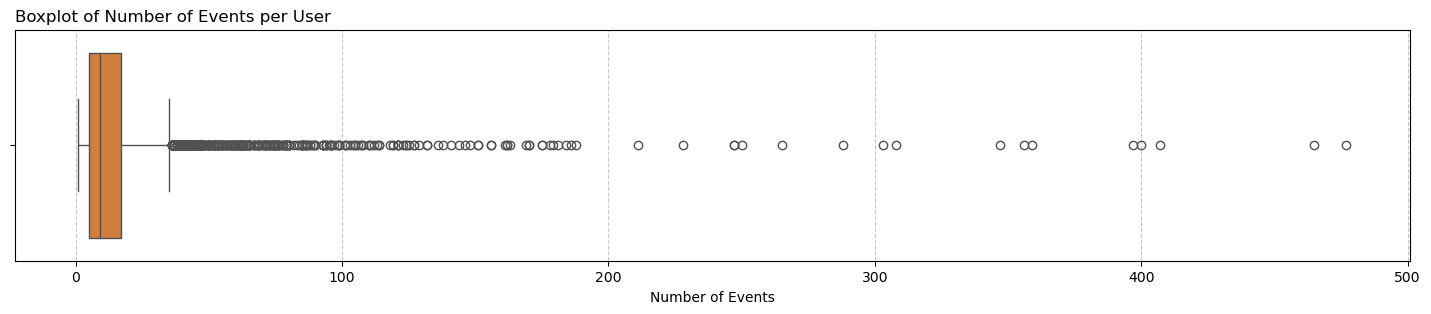

In [71]:
# Plot boxplot
plt.figure(figsize=(18, 3))
sns.boxplot(x=events_per_user, color='#E87C26')
plt.title('Boxplot of Number of Events per User', loc='left')
plt.xlabel('Number of Events')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


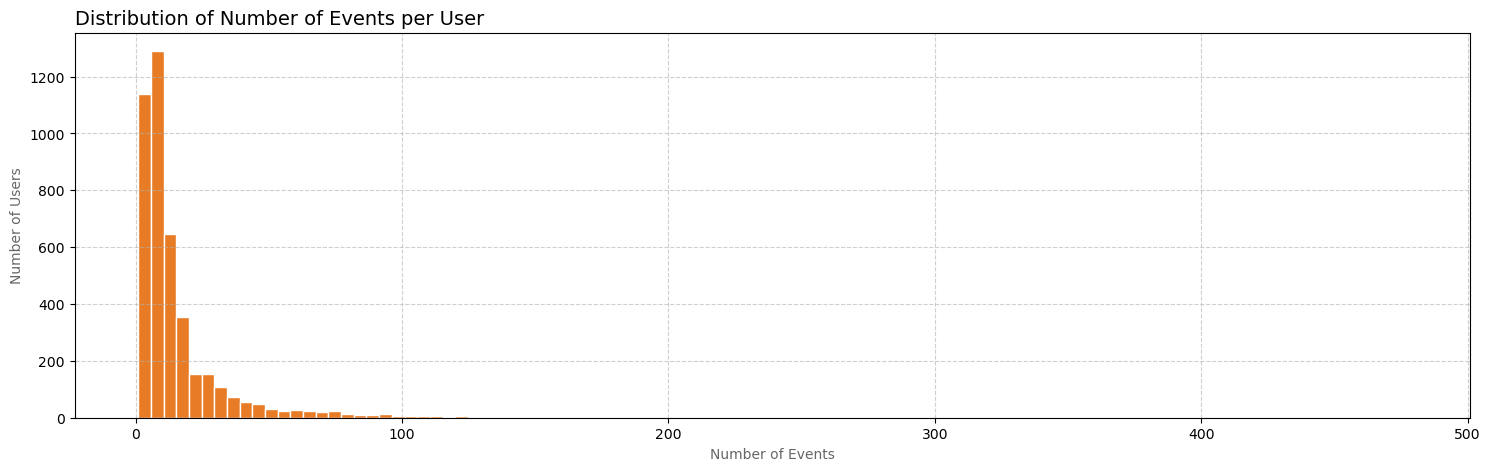

In [72]:
# Plot histogram
plt.figure(figsize=(18, 5))
plt.hist(events_per_user, bins=100, color="#E87C26", edgecolor='white')
plt.title('Distribution of Number of Events per User', fontsize=14, loc='left')
plt.xlabel('Number of Events', alpha=0.6)
plt.ylabel('Number of Users', alpha=0.6)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


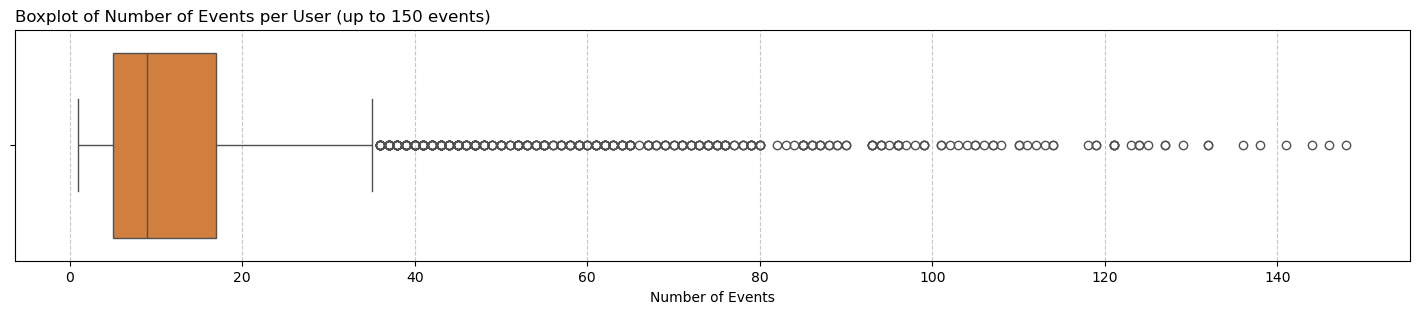

In [73]:
# Limit the number of events per user to a maximum of 150
events_per_user_limited = events_per_user[events_per_user <= 150]

# Plot boxplot
plt.figure(figsize=(18, 3))
sns.boxplot(x=events_per_user_limited, color='#E87C26')
plt.title('Boxplot of Number of Events per User (up to 150 events)', loc='left')
plt.xlabel('Number of Events')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


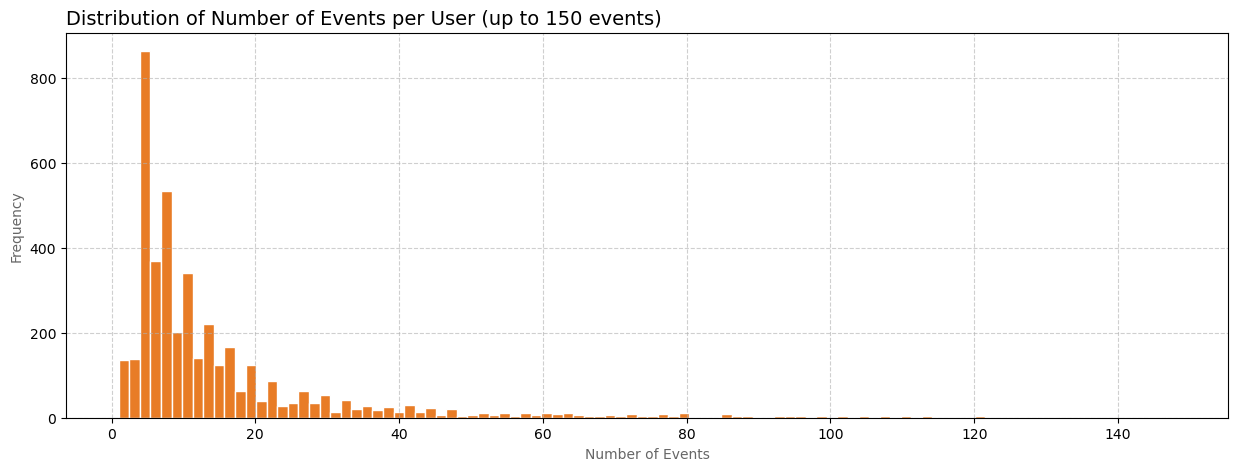

In [74]:
# Plot histogram
plt.figure(figsize=(15, 5))
plt.hist(events_per_user_limited, bins=100, color="#E87C26", edgecolor='white')
plt.title('Distribution of Number of Events per User (up to 150 events)', 
          fontsize=14, loc='left')
plt.xlabel('Number of Events', alpha=0.6)
plt.ylabel('Frequency', alpha=0.6)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**Conclusion:**

- The dataset contains **4,293** users. **65** users (about 1.5%) performed only one action.  
  The median is **9**, and the mean is around **17** — indicating a right-skewed distribution due to a "long tail".  
  25% of users performed **5 or fewer** events, and 75% performed **17 or fewer**.  
  Most users fall within the range of **5–17** events.  
  The maximum value is **477** events — a few "super-active" users create outliers and significantly raise the average.

- Most users perform fewer than **20 events**, with a peak around **5 events**.  
  The number of users performing **20 to 50 events** drops sharply, and beyond **50**, activity becomes extremely rare.  
  This distribution confirms that the majority of users engage minimally with the app.


##### Calculating the number of events by day

In [75]:
# Add a column with the event date
df['event_date'] = df['event_time'].dt.date

# Count the number of events per day
events_by_day = df.groupby('event_date').size().reset_index(name='event_count')

# Result
events_by_day


,event_date,event_count
0,2019-10-07,2544
1,2019-10-08,2496
2,2019-10-09,2026
3,2019-10-10,2242
4,2019-10-11,2030
5,2019-10-12,1840
6,2019-10-13,2632
7,2019-10-14,3032
8,2019-10-15,2722
9,2019-10-16,2728


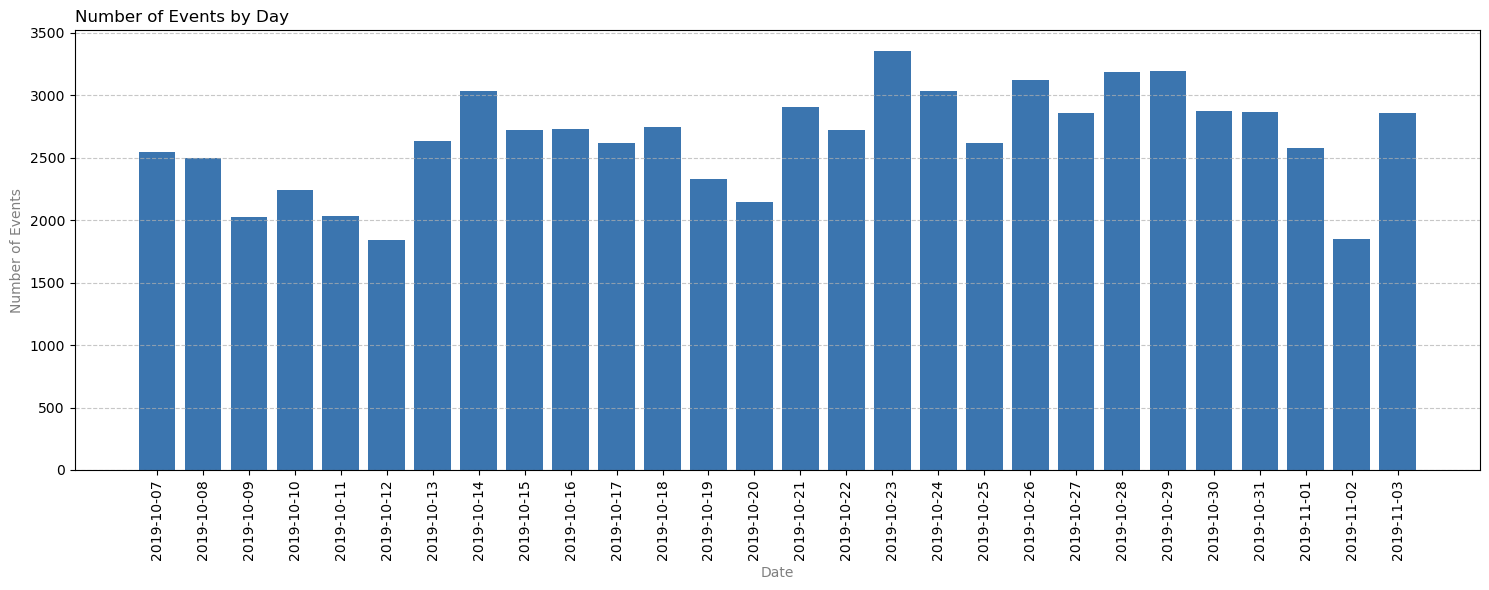

In [76]:
plt.figure(figsize=(15, 6))
plt.bar(events_by_day['event_date'], events_by_day['event_count'], color='#3b75af')

plt.title('Number of Events by Day', loc='left')
plt.xlabel('Date', alpha=0.5)
plt.ylabel('Number of Events', alpha=0.5)

# Configure X-axis tick labels
plt.xticks(events_by_day['event_date'], 
           events_by_day['event_date'], 
           rotation=90)  # Show each date as a label

plt.grid(axis='y', linestyle='--', alpha=0.7)  # Horizontal gridlines
plt.tight_layout()  # Adjust spacing for better layout
plt.show()


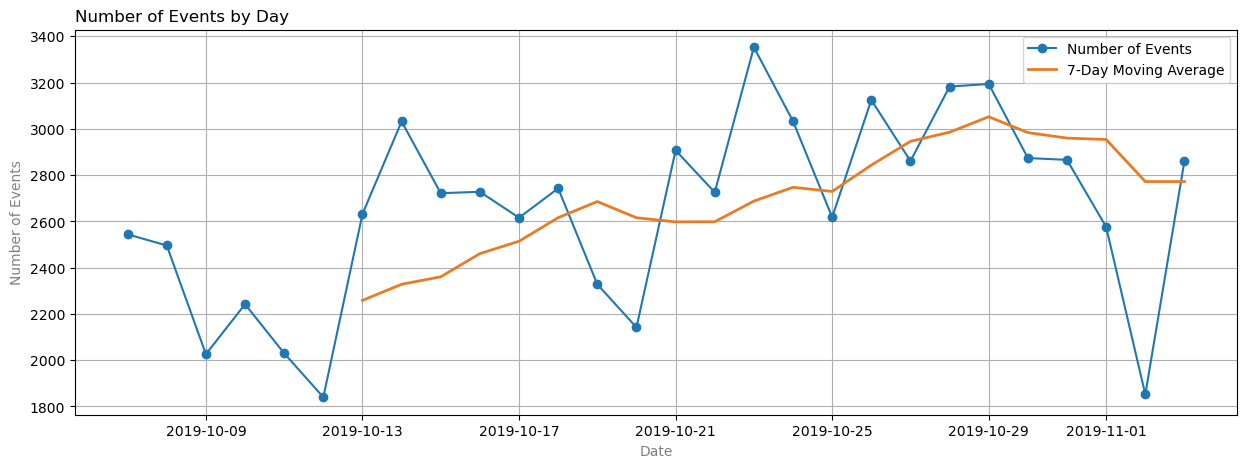

In [77]:
plt.figure(figsize=(15, 5))
plt.plot(events_by_day['event_date'], events_by_day['event_count'], marker='o', label='Number of Events')

# Add 7-day moving average
rolling_avg = events_by_day['event_count'].rolling(window=7).mean()
plt.plot(events_by_day['event_date'], rolling_avg, color='#E87C26', linewidth=2, label='7-Day Moving Average')

plt.title('Number of Events by Day', loc='left')
plt.xlabel('Date', alpha=0.5)
plt.ylabel('Number of Events', alpha=0.5)
plt.grid()
plt.legend()  # Add legend
plt.show()


**Conclusion:**
- User activity in the app fluctuates, with peaks on October 23 (3,353 events) and October 28–29 (3,183–3,194 events).  
  The lowest activity is observed on November 2 (1,852 events).

- On most days, activity remains within the range of 2,500–3,000 events.

- Toward the end of October, activity is consistently high — higher than at the beginning of the period.


##### Calculating the number of events by day of the week

In [78]:
# Add a column with the day of the week
df['day_of_week'] = df['event_time'].dt.day_name()

# Count the number of events by day of the week
events_by_weekday = df.groupby('day_of_week').size().reset_index(name='event_count')

# Order the days of the week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
events_by_weekday['day_of_week'] = pd.Categorical(events_by_weekday['day_of_week'], categories=days_order, ordered=True)
events_by_weekday = events_by_weekday.sort_values('day_of_week')

# Result
events_by_weekday


,day_of_week,event_count
1,Monday,11666
5,Tuesday,11138
6,Wednesday,10981
4,Thursday,10757
0,Friday,9967
2,Saturday,9145
3,Sunday,10496


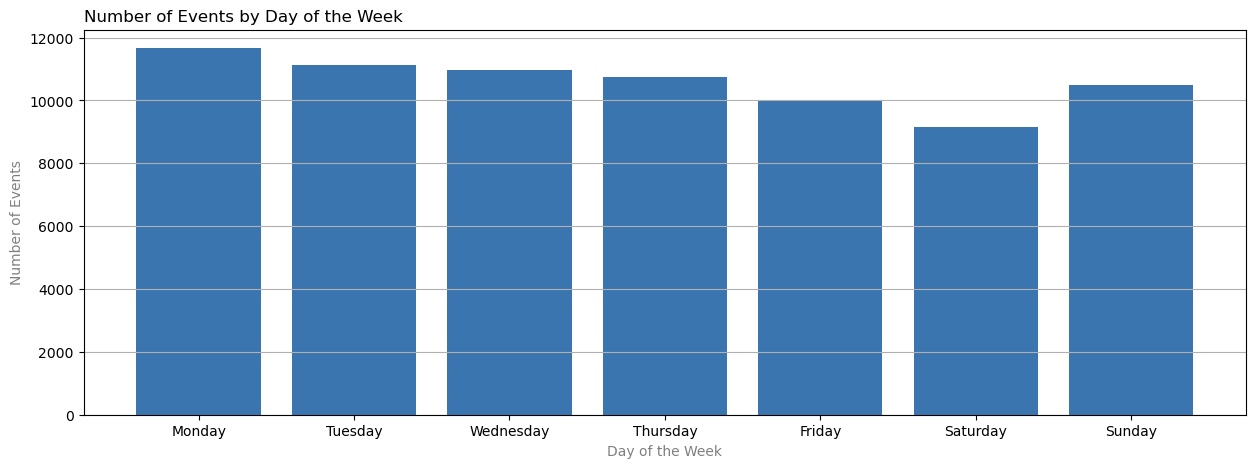

In [79]:
plt.figure(figsize=(15, 5))
plt.bar(events_by_weekday['day_of_week'], events_by_weekday['event_count'], color='#3b75af')
plt.title('Number of Events by Day of the Week', loc='left')
plt.xlabel('Day of the Week', alpha=0.5)
plt.ylabel('Number of Events', alpha=0.5)
plt.grid(axis='y')
plt.show()


**Conclusion:**
- User activity is higher at the beginning of the week and decreases toward the weekend.  
  The highest number of events occurs on Monday (**11,666** events), followed by a gradual decline through Friday (**9,967** events) and Saturday (**9,145** events).  
  Sunday shows a moderate increase in activity (**10,496** events).


#### Conversion to Target Action:
- Calculate the percentage of users who performed the `contacts_show` action.


In [80]:
# Determine total number of unique users
total_users = df['user_id'].nunique()

# Identify users who performed the target action
target_users = df[df['event_name'] == 'show_contacts']['user_id'].nunique()

# Calculate conversion rate
conversion_rate = (target_users / total_users) * 100
print(f'Conversion to show_contacts: {conversion_rate:.2f}%')


Conversion to show_contacts: 22.85%


##### By Event


In [81]:
# Define a function to calculate conversion by event 
# (users who performed the event vs. those who didn't)
def calculate_conversion(df, action_event, target_event='show_contacts'):
    # Users who performed the action_event
    action_users = df[df['event_name'] == action_event]['user_id'].unique()
    
    # Users who performed the target_event
    target_users = df[df['event_name'] == target_event]['user_id'].unique()
    
    # Conversion among those who did the action_event
    conversion_with_action = len(set(action_users) & set(target_users)) / len(action_users) * 100
    
    # Users who did not perform the action_event
    all_users = df['user_id'].unique()
    no_action_users = set(all_users) - set(action_users)
    
    # Conversion among those who did not do the action_event
    conversion_without_action = len(set(no_action_users) & set(target_users)) / len(no_action_users) * 100
    
    print(f'Conversion with {action_event}: {conversion_with_action:.2f}%')
    print(f'Conversion without {action_event}: {conversion_without_action:.2f}%')
    return conversion_with_action, conversion_without_action


In [82]:
# Get a list of unique events
unique_events = df['event_name'].unique()

# Apply the function to each event
for event in unique_events:
    calculate_conversion(df, event)
    print('-' * 35)  # Separator between events


Conversion with tips_show: 18.42%
Conversion without tips_show: 31.17%
-----------------------------------
Conversion with map: 19.85%
Conversion without map: 24.39%
-----------------------------------
Conversion with search: 22.63%
Conversion without search: 22.99%
-----------------------------------
Conversion with photos_show: 30.96%
Conversion without photos_show: 20.08%
-----------------------------------
Conversion with favorites_add: 38.75%
Conversion without favorites_add: 21.44%
-----------------------------------
Conversion with show_contacts: 100.00%
Conversion without show_contacts: 0.00%
-----------------------------------
Conversion with contacts_call: 100.00%
Conversion without contacts_call: 18.82%
-----------------------------------
Conversion with advert_open: 18.38%
Conversion without advert_open: 23.80%
-----------------------------------
Conversion with tips_click: 31.06%
Conversion without tips_click: 22.19%
-----------------------------------


High conversion rates observed for `favorites_add`, `photos_show`, and `tips_click`:

- `favorites_add` — 38.75% among those who added listings to favorites vs. 21.44% among those who didn't.  
  This may indicate strong user interest in saved listings.

- `photos_show` — 30.96% among users who viewed photos vs. 20.08% among those who did not.  
  This confirms that visual content positively influences decision-making.

- `tips_click` — 31.06% vs. 22.19%.  
  Users who engage with recommendations are more likely to complete target actions.

- `search` — 22.63% vs. 22.99%.  
  Interaction with search has almost no impact on conversion.

- `map` — 19.85% vs. 24.39%.  
  Users who open the map are less likely to perform `show_contacts`, which may suggest they are exploring alternatives or still in the decision phase.

- `tips_show` — 18.42% vs. 31.17%.  
  Users who saw recommendations but didn’t click on them show lower conversion, which may indicate the recommendations are not relevant.  
  However, this is hard to interpret definitively, as `tips_show` is likely an automatic event triggered at app launch or product page visit — and over half of users drop off after the first session.

- `advert_open` — 18.38% vs. 23.80%.  
  Simply opening a listing does not strongly influence conversion, which may point to weak engagement driven by the listing text itself.


#### By the number of sessions

In [85]:
# Create a categorical column for grouping by session count
df['session_group'] = pd.cut(
    df['sessions_count'], 
    bins=[0, 1, 2, 3, 4, 5, float('inf')],  # Define boundaries up to infinity
    labels=['1', '2', '3', '4', '5', '>5']  # Category labels
)

# Count the total number of users in each group (with observed=True)
total_users = df.groupby('session_group', observed=True)['user_id'].nunique()

# Count users who performed the show_contacts event (with observed=True)
show_contacts_users = (
    df[df['event_name'] == 'show_contacts']
    .groupby('session_group', observed=True)['user_id']
    .nunique()
)

# Calculate conversion rate
conversion_rate = (show_contacts_users / total_users) * 100
conversion_rate = conversion_rate.fillna(0)

# Output the result
print(total_users)
conversion_rate


session_group
1     2300
2      878
3      462
4      239
5      109
>5     305
Name: user_id, dtype: int64


session_group
1     14.782609
2     22.209567
3     34.415584
4     30.962343
5     42.201835
>5    54.754098
Name: user_id, dtype: float64

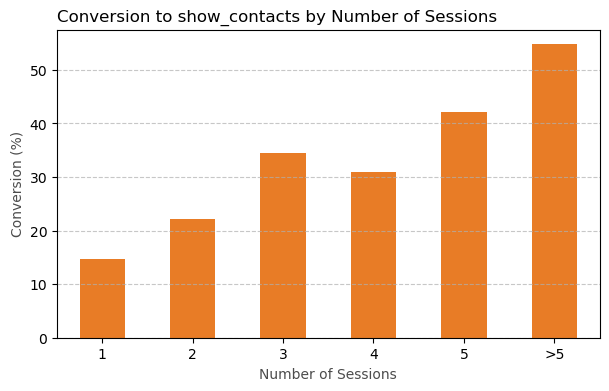

In [87]:
plt.figure(figsize=(7, 4))
conversion_rate.plot(kind='bar', color='#E87C26')
plt.title('Conversion to show_contacts by Number of Sessions', loc='left')
plt.xlabel('Number of Sessions', alpha=0.7)
plt.ylabel('Conversion (%)', alpha=0.7)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


**Conclusion:**

- Users with only 1 session have a conversion rate of approximately 14.78%. With 2 sessions, the conversion rate increases to 22.21%. Having 3–5 sessions results in a consistently high conversion rate, reaching 42.20% for users with 5 sessions. Users with more than 5 sessions show the highest conversion — 54.75%.

- Conversion to `show_contacts` increases almost linearly with the number of sessions. This suggests that users with more sessions are more engaged and more likely to perform the target action.


#### By session length

In [89]:
df['session_duration_group'] = pd.cut(
    df['session_duration'],
    bins=[-1, 1, 5, 15, 30, 60, float('inf')],
    labels=['<1 min', '1-5 min', '5-15 min', '15-30 min', '30-60 min', '>60 min']
)

# Group users by session duration with observed=True to suppress the warning
duration_segment = (
    df.groupby('session_duration_group', observed=True)['user_id']
    .nunique()
    .reset_index()
)
duration_segment.columns = ['session_duration_group', 'user_count']

# Display the result
duration_segment


,session_duration_group,user_count
0,<1 min,1449
1,1-5 min,1392
2,5-15 min,1869
3,15-30 min,1280
4,30-60 min,786
5,>60 min,264


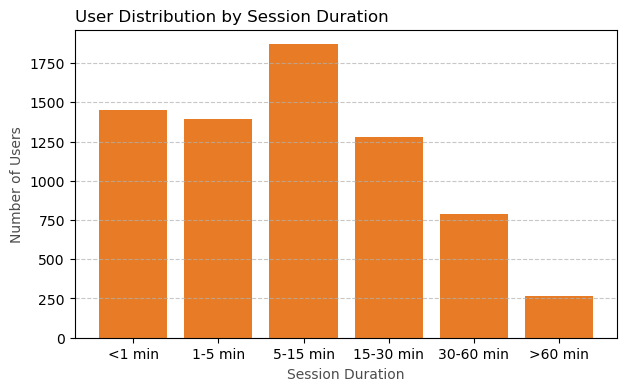

In [91]:
plt.figure(figsize=(7, 4))
plt.bar(duration_segment['session_duration_group'], duration_segment['user_count'], color='#E87C26')
plt.title('User Distribution by Session Duration', loc='left')
plt.xlabel('Session Duration', alpha=0.7)
plt.ylabel('Number of Users', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [93]:
conversion_by_duration = (
    df[df['event_name'] == 'show_contacts']
    .groupby('session_duration_group', observed=True)['user_id']
    .nunique()
    / df.groupby('session_duration_group', observed=True)['user_id']
    .nunique()
) * 100

conversion_by_duration.to_frame()


,user_id
session_duration_group,
<1 min,15.873016
1-5 min,17.169540
5-15 min,18.031033
15-30 min,20.859375
30-60 min,26.463104
>60 min,35.984848


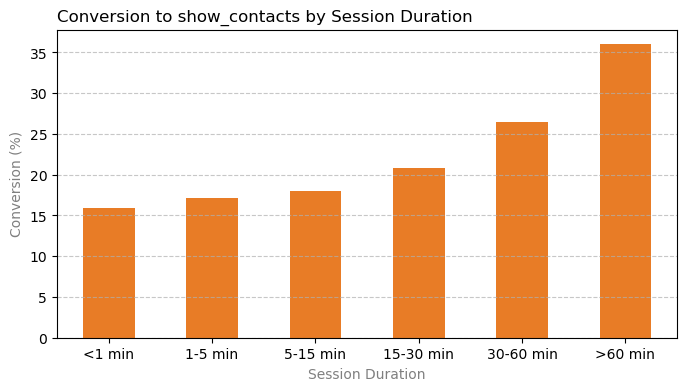

In [95]:
# Visualization
plt.figure(figsize=(8, 4))
conversion_by_duration.plot(kind='bar', color='#E87C26')
plt.title('Conversion to show_contacts by Session Duration', loc='left')
plt.xlabel('Session Duration', alpha=0.5)
plt.ylabel('Conversion (%)', alpha=0.5)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


**Conclusion:**

**User distribution by session duration:**  
The largest group of users spend 5–15 minutes in the app — this is the most populous segment. The second largest group has sessions lasting 1–5 minutes. The fewest users spend more than 60 minutes in the app — this is a rare case.

**Conversion to the target action (show_contacts):**  
Conversion increases with session duration:  
- <1 min — 15.87% (lowest conversion),  
- 1–5 min — 17.17%,  
- 5–15 min — 18.03%,  
- 30–60 min — 26.46%,  
- 60 min and more — 35.98% (highest conversion).

**Key takeaways:**  
Users with long sessions (>30 min) convert almost twice as often as those with sessions shorter than 1 minute.  
The lowest conversion is observed among users with very short sessions (<1 min), which may indicate rapid exits, lack of interest, or technical issues.

**Recommendations:**  
Analyze users with short sessions to identify reasons for early drop-off.  
Encourage users with short sessions to continue using the app (e.g., through personalized offers or notifications).  
Focus on retaining users with sessions of 15+ minutes, as they show the highest conversion potential.


## User Segmentation  
### By Installation Source:  
Grouping users by the `source` column: yandex, google, other. This will allow us to evaluate the effectiveness of different advertising channels.

Rationale:  
The source of installation directly affects user behavior in the app. Different advertising channels may attract users with varying levels of engagement. For example:

- Users from **Yandex** may show a higher level of trust in the service, as it is a local platform.  
- **Google** often brings in a broader audience, but conversion rates may be lower due to high-volume traffic.  
- Other sources (**other**) may include organic traffic or social media ad campaigns, which also influence user behavior.

This segmentation will help identify which channels bring the most engaged users and allow for cost optimization by reducing spending on less effective campaigns. If it turns out that users from a specific source are more likely to complete target actions, it would be beneficial for the client to increase advertising efforts in that channel.


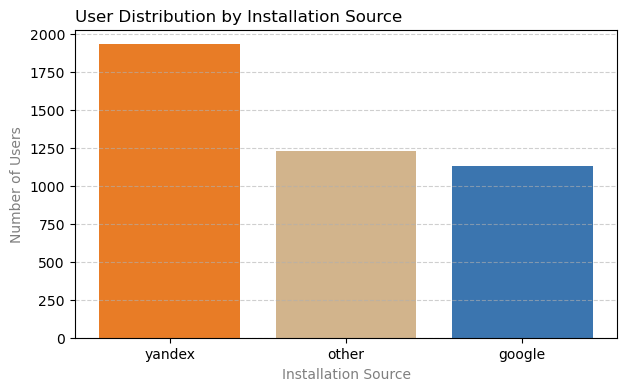

In [97]:
# Group users by installation source
source_segment = df.groupby('source')['user_id'].nunique().reset_index()
source_segment.columns = ['source', 'user_count']

# Sort in descending order
source_segment = source_segment.sort_values(by='user_count', ascending=False)

# Visualize user distribution by installation source
plt.figure(figsize=(7, 4))
plt.bar(source_segment['source'], source_segment['user_count'], color=['#E87C26', '#D2B48C', '#3b75af'])
plt.title('User Distribution by Installation Source', loc='left')
plt.xlabel('Installation Source', alpha=0.5)
plt.ylabel('Number of Users', alpha=0.5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


The majority of users come from the `yandex` channel.

Now let's answer the question:  
Which user group has the highest conversion rate to the target action?

In [98]:
# Calculate conversion to show_contacts for each source
conversion_by_source = (
    df[df['event_name'] == 'show_contacts']
    .groupby('source')['user_id']
    .nunique()
    / df.groupby('source')['user_id'].nunique()
) * 100

conversion_by_source.to_frame()


,user_id
source,
google,24.357839
other,18.536585
yandex,24.715615


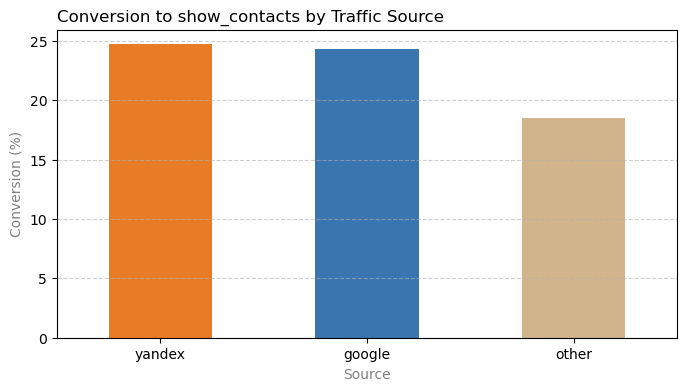

In [99]:
# Visualize conversion rate by traffic source
conversion_by_source.sort_values(ascending=False).plot(kind='bar', figsize=(8, 4), color=['#E87C26', '#3b75af', '#D2B48C'])
plt.title('Conversion to show_contacts by Traffic Source', loc='left')
plt.ylabel('Conversion (%)', alpha=0.5)
plt.xlabel('Source', alpha=0.5)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


**Conclusion**

- **User Distribution:**  
The majority of users came from Yandex — around 1,800 users.  
The second-largest group is from the "other" category (approximately 1,250 users).  
The fewest users installed the app via Google (around 1,100).

- **Conversion to the target action (show_contacts):**  
Yandex shows the highest conversion rate — 24.72%.  
Google follows closely with 24.36%.  
Users from the "other" category demonstrate the lowest conversion — 18.54%.

---

Next task: determine which user group is more likely to return to the mobile app frequently (retention rate).


In [100]:
# Create an empty dictionary to store retention results for each source
retention_by_source = {}

# Calculate retention rate for each source
for source in df['source'].unique():
    filtered_df = df[df['source'] == source].copy()  # create a copy of the DataFrame
    retention_by_source[source] = calculate_retention(filtered_df)


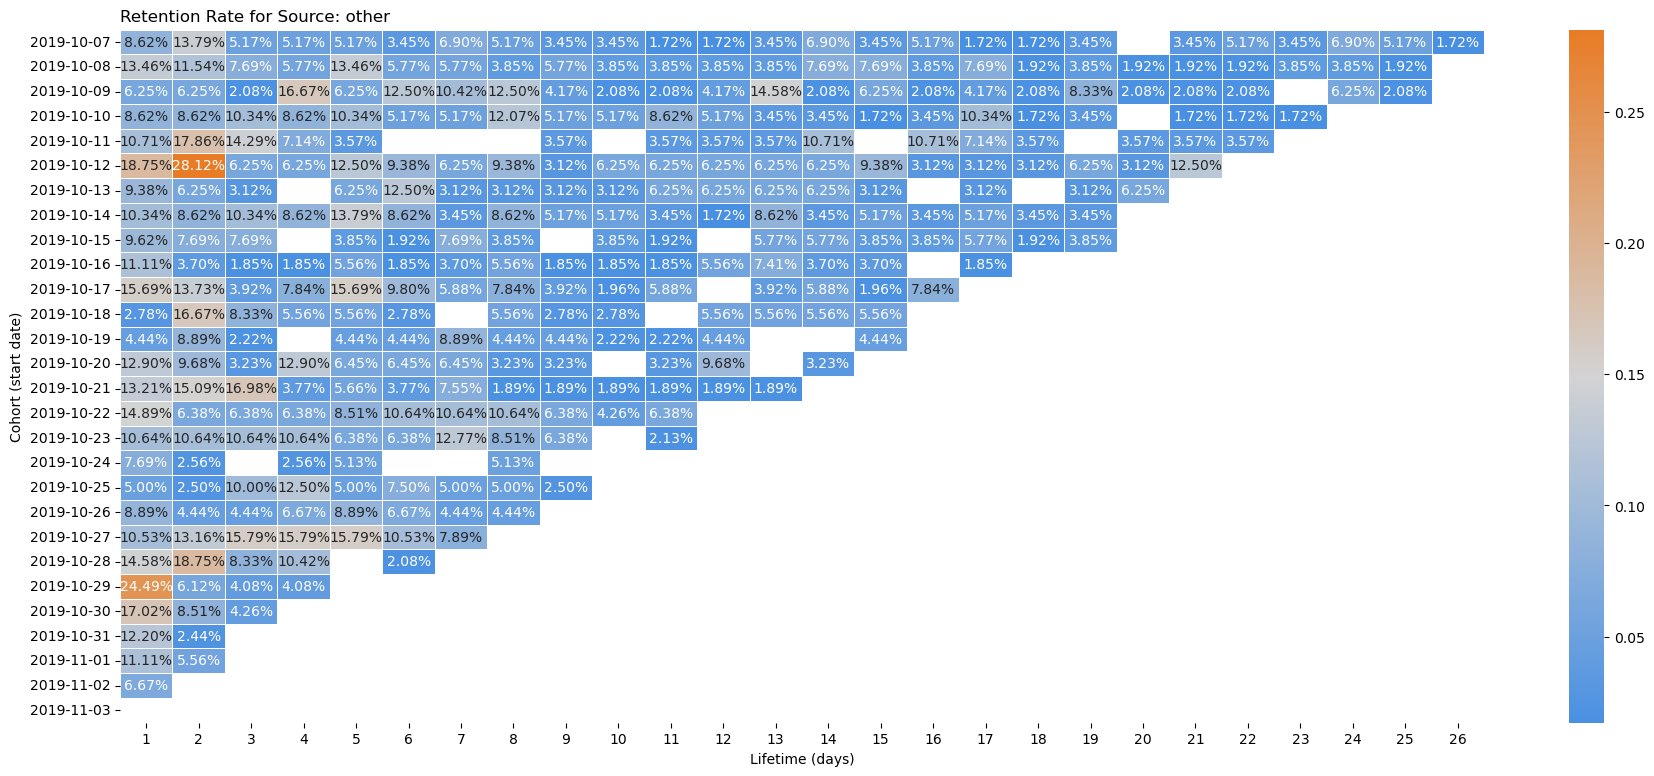

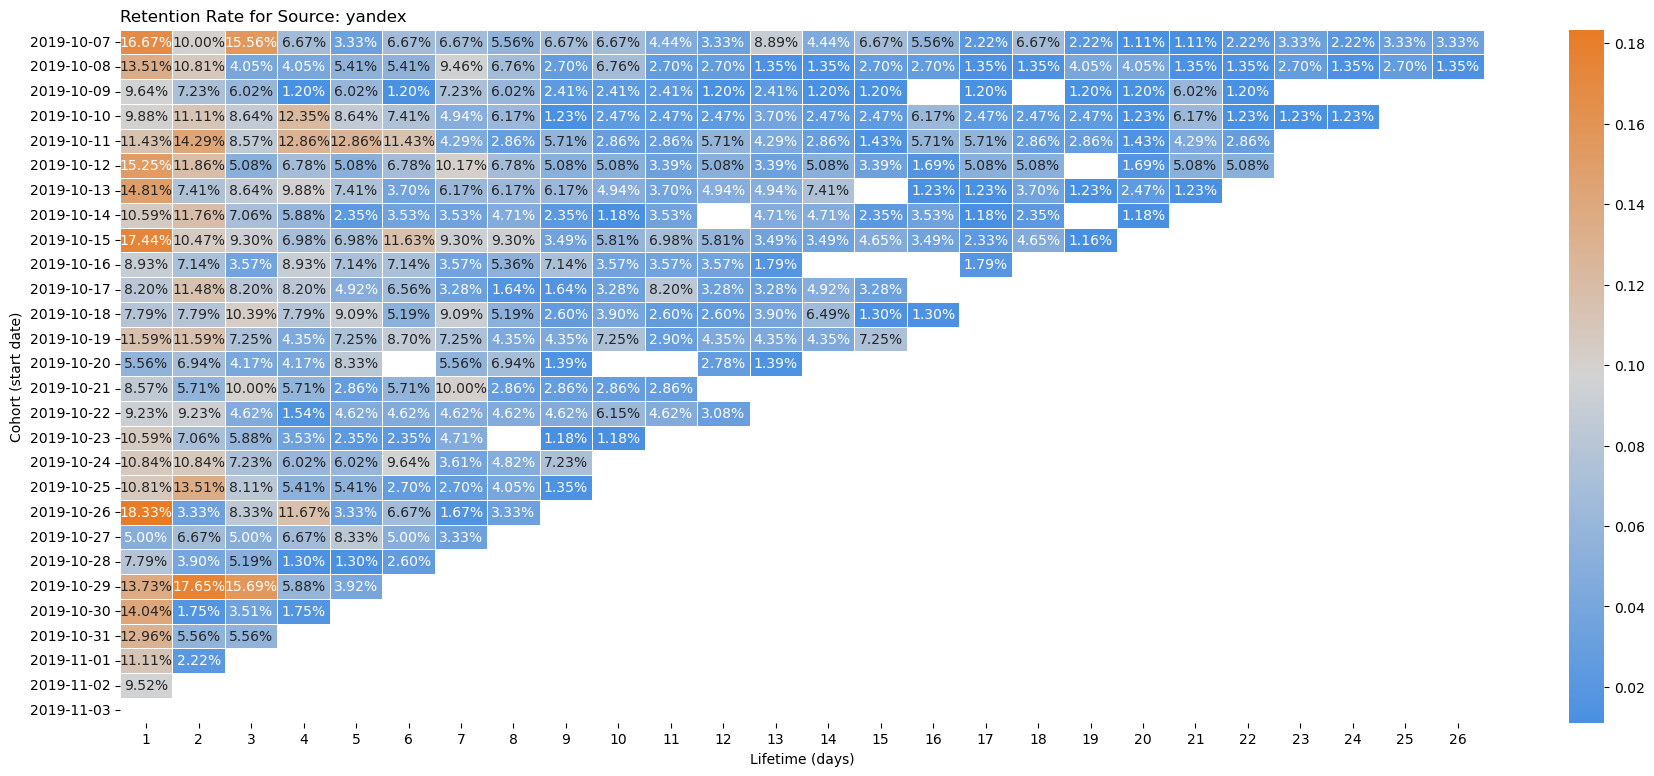

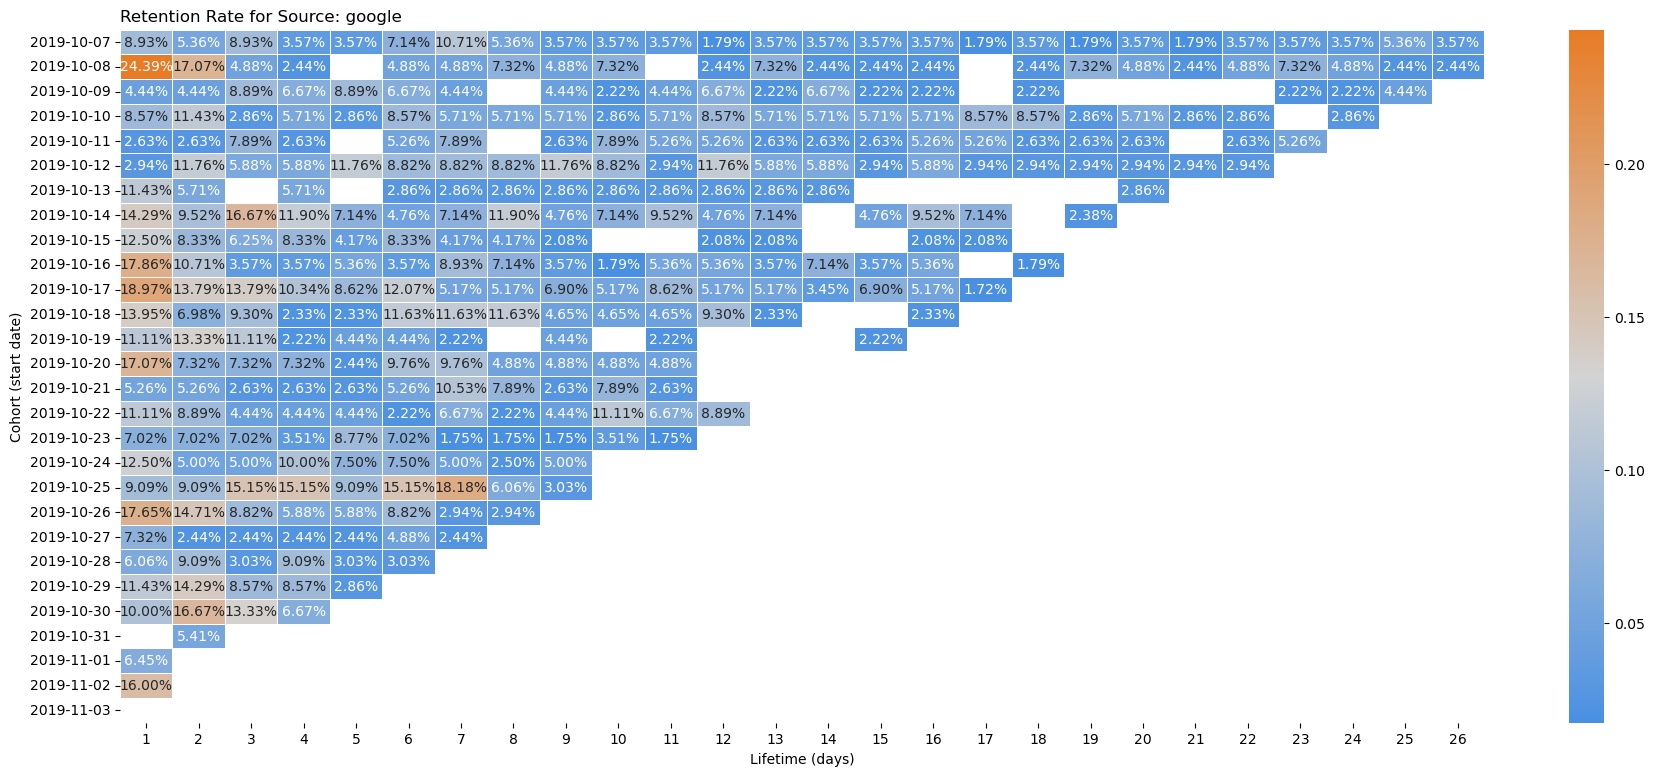

In [101]:
# Visualize retention rate for each source group
for source, retention in retention_by_source.items():
    plot_retention_heatmap(retention, title=f'Retention Rate for Source: {source}')


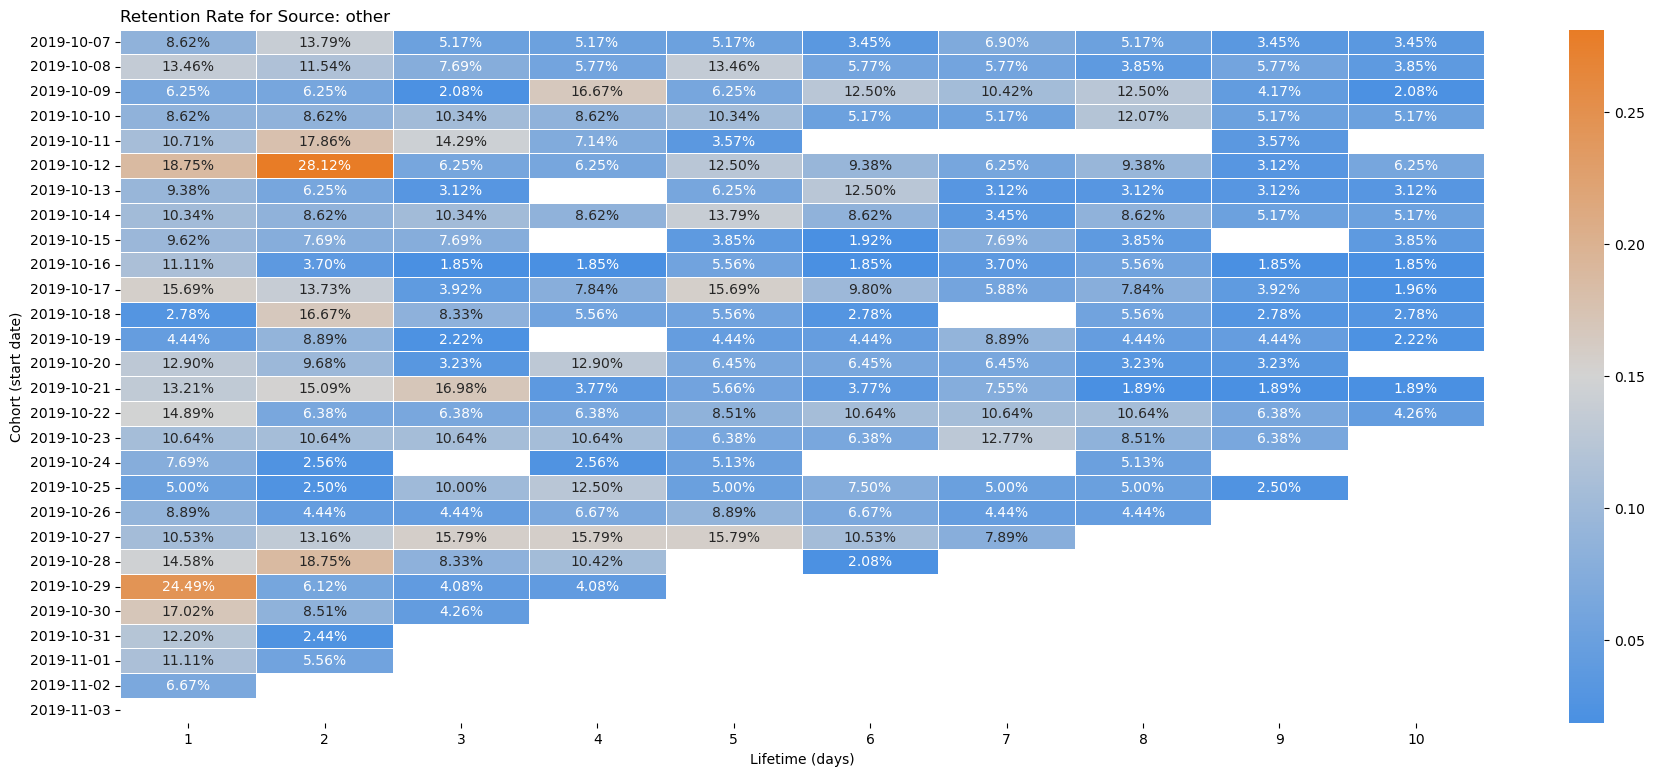

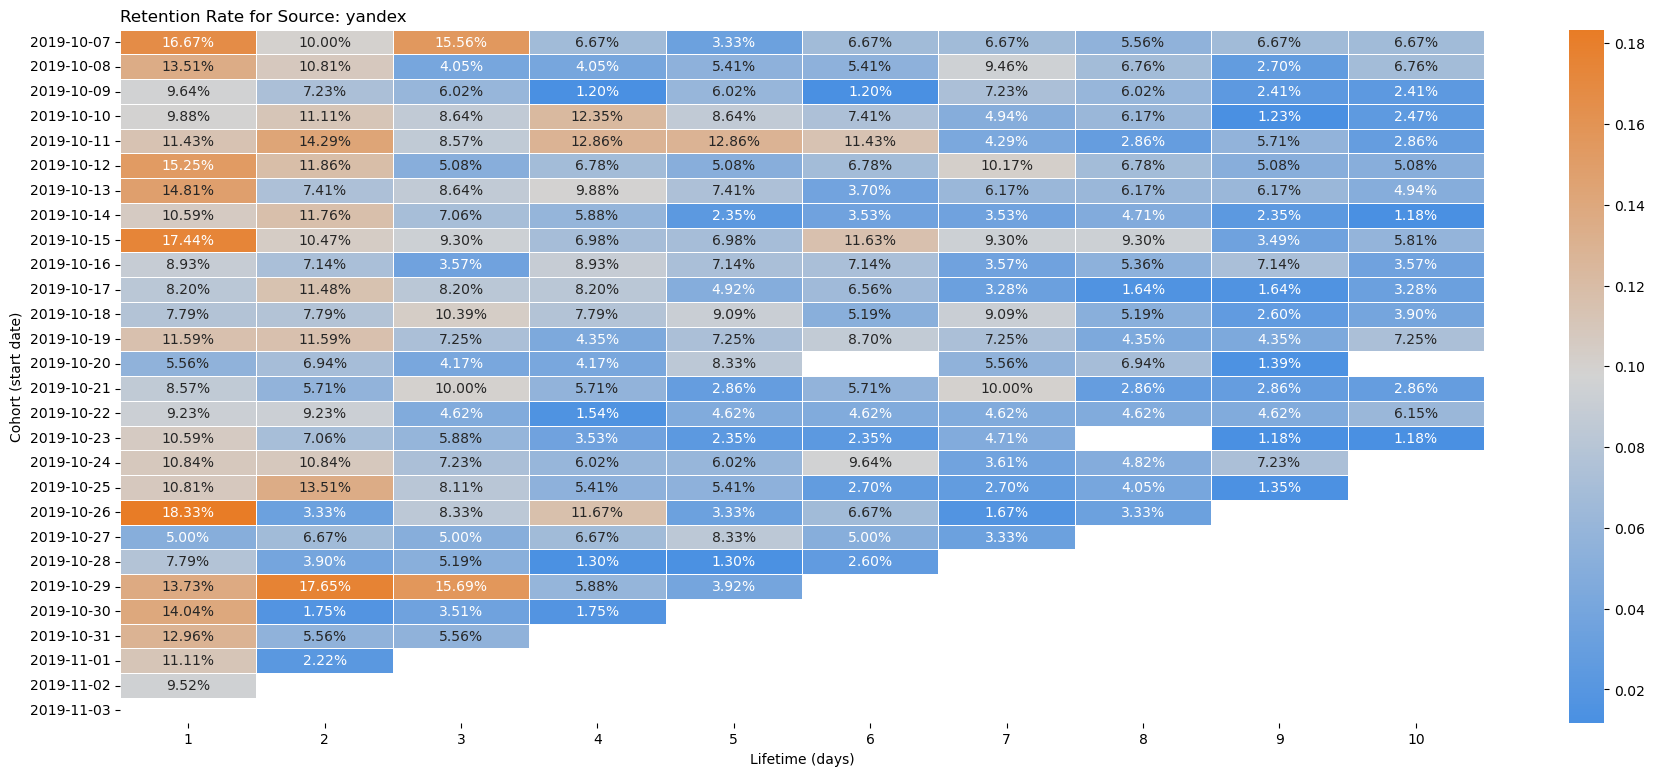

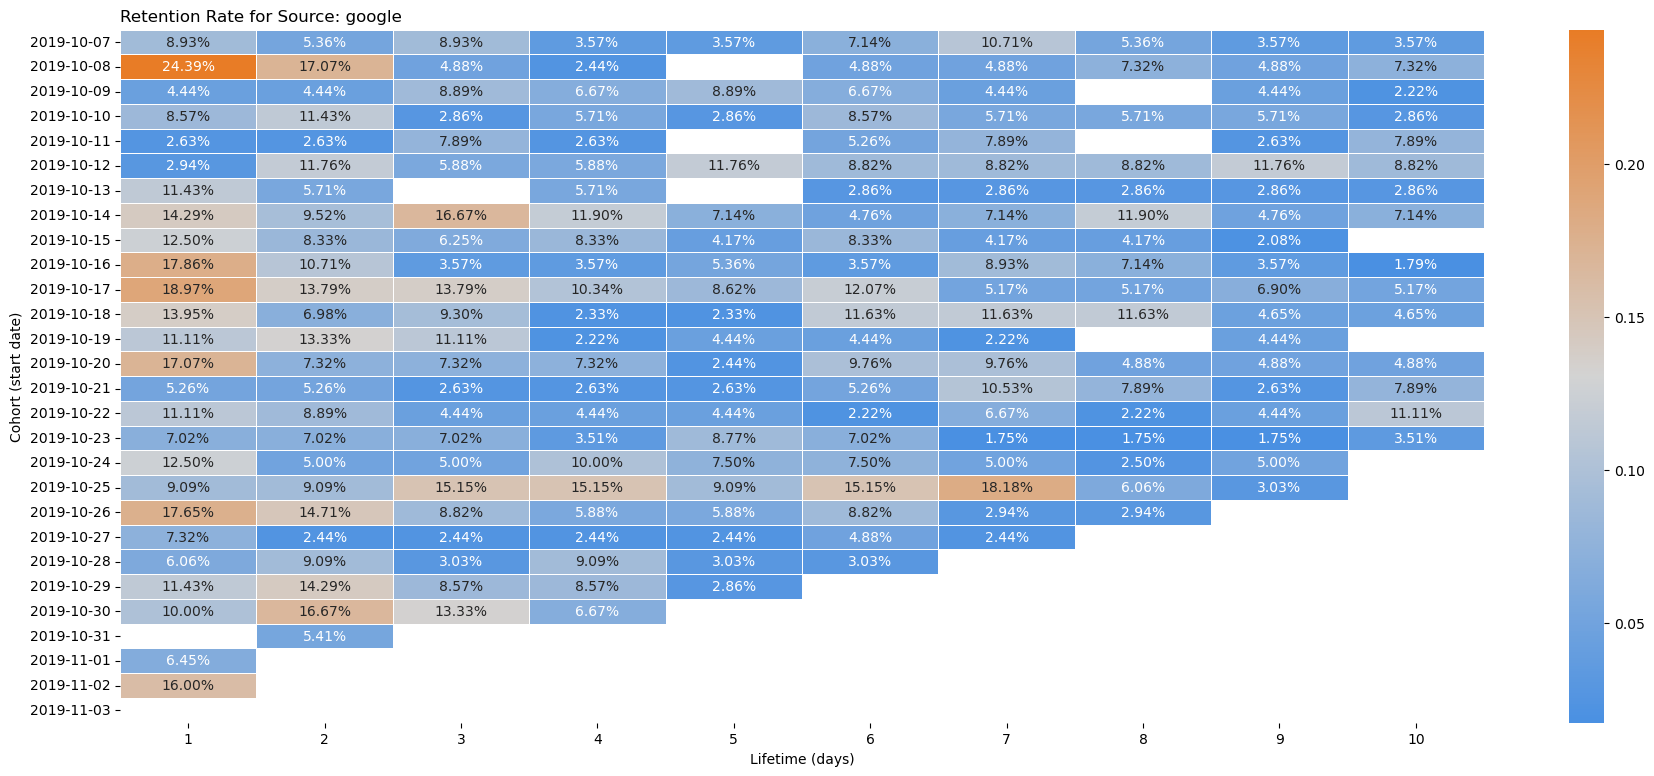

In [102]:
# Visualize retention with a 10-day analysis horizon
for source, retention in retention_by_source.items():
    plot_retention_heatmap(
        retention,
        title=f'Retention Rate for Source: {source}',
        horizon_days=10  # set analysis horizon
    )


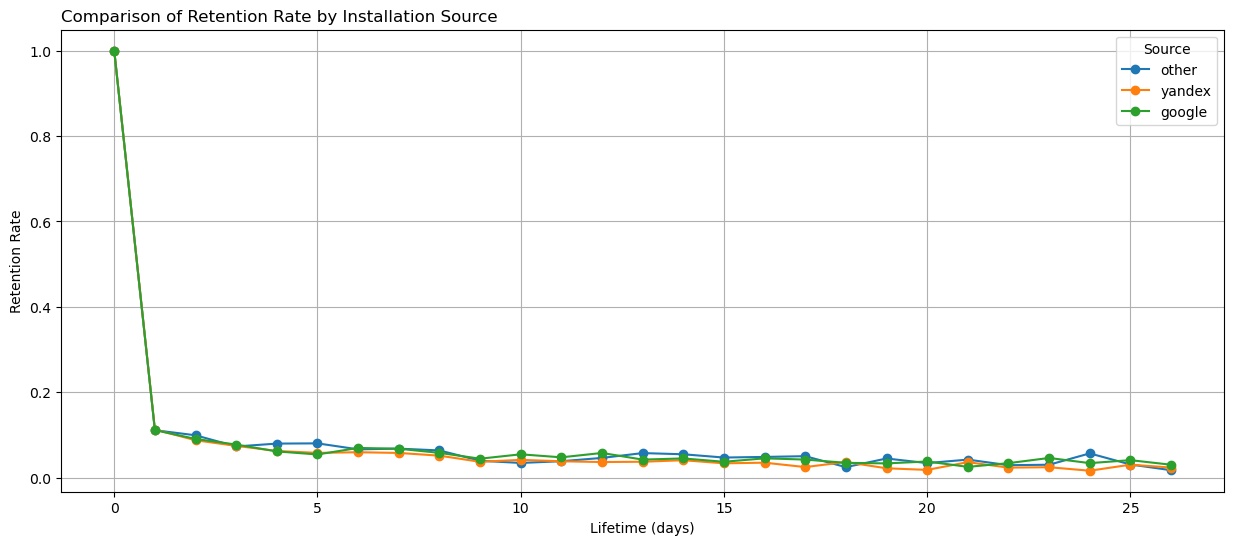

In [104]:
plt.figure(figsize=(15, 6))

for source, retention in retention_by_source.items():
    plt.plot(
        retention.columns,
        retention.mean(),  # average retention across cohorts
        marker='o',
        label=f'{source}'
    )

plt.title('Comparison of Retention Rate by Installation Source', loc='left')
plt.xlabel('Lifetime (days)')
plt.ylabel('Retention Rate')
plt.legend(title='Source')
plt.grid(True)
plt.show()


**Conclusion:**

- The issue of low retention after the first day is similar across all sources, suggesting that the main problem lies in the user’s first session — possibly due to an unclear interface.

- Yandex and Google show similar retention curves and relatively high retention rates compared to the "other" source.  
  Yandex demonstrates higher retention on Day 2.

- **Yandex is the most effective channel** — it brings in the highest number of users, shows the highest retention on the critical second day, and has the highest conversion rate.

- The **"other"** source shows the lowest retention, which may indicate a less relevant audience or lower-quality user acquisition.


## Hypothesis Testing

### First Hypothesis:
Some users installed the app via a Yandex link, others via Google.  
We want to test whether these two groups show different conversion rates to contact views.

**Null Hypothesis (H₀):**  
There is no difference in the conversion rate to contact views between users from Yandex and Google.

**Alternative Hypothesis (H₁):**  
The conversion rate to contact views differs between these two groups.

We will conduct a statistical Z-test for proportions, which allows us to compare success rates (conversion rates) between two independent groups.


In [105]:
# Count the number of users from Yandex and Google
yandex_users = df[df['source'] == 'yandex']['user_id'].nunique()
google_users = df[df['source'] == 'google']['user_id'].nunique()

# Count users who performed show_contacts (conversions)
yandex_converted = df[(df['source'] == 'yandex') & (df['event_name'] == 'show_contacts')]['user_id'].nunique()
google_converted = df[(df['source'] == 'google') & (df['event_name'] == 'show_contacts')]['user_id'].nunique()

# Conversion proportions
yandex_conversion = yandex_converted / yandex_users
google_conversion = google_converted / google_users

# Prepare data for Z-test
counts = np.array([yandex_converted, google_converted])  # Number of successes
nobs = np.array([yandex_users, google_users])  # Total observations

# Perform the Z-test
z_stat, p_value = proportions_ztest(counts, nobs)

# Display the results
print(f'Yandex Conversion: {yandex_conversion:.2%}')
print(f'Google Conversion: {google_conversion:.2%}')
print(f'p-value: {p_value:.4f}')

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. Conversion rates are significantly different.")
else:
    print("Fail to reject the null hypothesis. No significant difference in conversion rates.")


Yandex Conversion: 24.72%
Google Conversion: 24.36%
p-value: 0.8244
Fail to reject the null hypothesis. No significant difference in conversion rates.


### Custom Hypothesis:
Users who click on recommended listings (`tips_click`) have a higher conversion rate to contact views (`contacts_show` / `show_contacts`) compared to users who do not click on recommendations.

**Null Hypothesis (H₀):**  
The conversion rate to contact views for users who click on recommendations is the same as for those who do not.

**Alternative Hypothesis (H₁):**  
The conversion rate to contact views is higher among users who click on recommended listings.

We will also apply a Z-test for proportions.


In [106]:
# Count users who clicked on tips_click
tips_click_users = df[df['event_name'] == 'tips_click']['user_id'].unique()

# Group of users with tips_click
tips_click_group = df[df['user_id'].isin(tips_click_users)]

# Group of users without tips_click
no_tips_click_group = df[~df['user_id'].isin(tips_click_users)]

# Number of users in each group
n_tips_click = tips_click_group['user_id'].nunique()
n_no_tips_click = no_tips_click_group['user_id'].nunique()

# Number of conversions (show_contacts) in each group
converted_tips_click = tips_click_group[tips_click_group['event_name'] == 'show_contacts']['user_id'].nunique()
converted_no_tips_click = no_tips_click_group[no_tips_click_group['event_name'] == 'show_contacts']['user_id'].nunique()

# Conversion proportions
tips_click_conversion = converted_tips_click / n_tips_click
no_tips_click_conversion = converted_no_tips_click / n_no_tips_click


In [107]:
counts = np.array([converted_tips_click, converted_no_tips_click])  # Number of successes (conversions)
nobs = np.array([n_tips_click, n_no_tips_click])  # Number of observations

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')  # Test whether tips_click conversion > no_tips_click

# 7. Display results
print(f'Conversion rate for users with tips_click: {tips_click_conversion:.2%}')
print(f'Conversion rate for users without tips_click: {no_tips_click_conversion:.2%}')
print(f'p-value: {p_value:.4f}')

alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. Conversion is higher for users with tips_click.")
else:
    print("Fail to reject the null hypothesis. The difference in conversion is not statistically significant.")


Conversion rate for users with tips_click: 31.06%
Conversion rate for users without tips_click: 22.19%
p-value: 0.0001
Reject the null hypothesis. Conversion is higher for users with tips_click.


## Conclusions

---

### Data Preprocessing

The data was provided as two separate DataFrames and merged into one.  
Columns were converted to `snake_case`, data types were cast to `datetime` and `object`.  
No missing values or explicit duplicates were found.  
94 implicit duplicates were removed, reducing the dataset size to 74,150 rows.  
Duplicate events like `show_contacts` and `search_1–7` were consolidated.  
Logs were split into sessions using a 30-minute timeout rule.


---

### Exploratory Data Analysis

#### General Overview

- The most frequent event is `tips_show` (40,052 actions), followed by `photos_show` (9,997) and `search` (6,783).  
  The rarest events are `tips_click` (813) and `contacts_call` (541).

- The highest number of users is observed for `tips_show` — 2,801 users, followed by `search` (1,666), `map` (1,456),  
  `photos_show` (1,095), and `show_contacts` (981).  
  The least-used events include `advert_open` (751), `favorites_add` (351), `tips_click` (322), and `contacts_call` (213).

- The data covers the period from October 7 to November 3, 2019.

- User activity varies over time, with peaks of around 1,000 logs per day.  
  Activity is relatively higher in the middle and at the end of the observed period.  
  Peak usage occurs between 12:00 and 21:00, with the highest activity around 15:00.  
  There is a noticeable drop between 16:00 and 19:00. The lowest activity is between 2:00 and 6:00.

- Most users came through the `yandex` channel.


---

#### **Key Metrics (Summary):**  

##### **Retention Rate:**  
- On Day 2, **12–16%** of users return; by Day 5, this drops to **5–8%**.  
- Retention stabilizes at around **2–4%** by Day 7–8.  
- Some anomalies show spikes in retention at later stages (e.g., 8.6% on Day 7).

##### **Session Duration:**  
- **53% of users** complete only one session.  
  **158 users (3.68%)** with one session spent less than 1 minute.  
  This small share may indicate technical or UX issues or low engagement.  
  But overall, it's not a critical concern.

- **Average session duration:** 12.88 minutes (median: 5.59 min).  
- **2,089 sessions (20%)** had zero duration.  
  These were analyzed and likely reflect users who quickly opened and closed the app — not a logging error.  
  **3,072 sessions (30%)** were shorter than 1 minute.  
  **519 sessions (5%)** were longer than 48.52 minutes — likely outliers.

- **Average session duration per user:** 14.26 minutes; median: 9.38 minutes.  
  **83 users (2%)** had zero-duration sessions,  
  **360 users (8%)** — less than 1 minute.  
  **215 users (5%)** spent more than 44 minutes in the app.

##### **Event Frequency:**  
- 25% of users performed **5 or fewer events**, 75% — **17 or fewer**.  
- Max number of events per user: **477**.  
- **65 users (1.5%)** performed only one action.

##### **Activity Over Time:**  
- Activity peaks: October 23 (**3,353 events**) and October 28–29 (**3,183–3,194 events**).  
- Most active day: Monday (**11,666 events**); least active: Saturday (**9,145 events**).  
- Sunday shows increased activity: **10,496 events**.

##### **Conversion Rate**

Overall conversion to the target action (viewing contacts): **22.85%**

- **By session count:** Conversion increases almost linearly with session count.  
  1 session — **14.78%**,  
  2 sessions — **22.21%**,  
  more than 5 sessions — **54.75%**.

- **By session duration:**  
  Most users stay in the app for 5–15 minutes;  
  second-largest group: 1–5 minutes;  
  very few stay more than 60 minutes.  
  Conversion grows with longer sessions:  
  - <1 min — **15.87%** (lowest),  
  - 1–5 min — **17.17%**,  
  - 5–15 min — **18.03%**,  
  - 30–60 min — **26.46%**,  
  - 60 min and more — **35.98%** (highest).

- **By event:** High conversion observed for:  
  - `favorites_add` — **38.75%** vs **21.44%**  
  - `photos_show` — **30.96%** vs **20.08%**  
  - `tips_click` — **31.06%** vs **22.19%**


---

### Segmentation

Users were segmented by installation source (`yandex`, `google`, `other`).

**Which group shows higher conversion to the target action?**

- Yandex has the highest conversion — **24.72%**  
- Google follows closely — **24.36%**  
- The "other" group shows the lowest — **18.54%**

**Which group has the highest retention?**

- Low Day-1 retention is a common issue across all sources — suggesting it's related to first-session experience (e.g., unclear interface).

- Yandex and Google show similar retention curves and better retention than the "other" group.  
  Yandex shows slightly higher retention on Day 2.

- **Yandex is the most effective channel**: brings the most users, has the highest Day-2 retention, and the highest conversion.

- The "other" group shows the weakest retention — possibly due to untargeted or low-quality user acquisition.


---

### Hypothesis Testing

- **Z-test #1:**  
  Compared conversion rates between users from Yandex and Google.  
  Result: no statistically significant difference in conversion.

- **Z-test #2:**  
  Compared conversion rates between users who clicked on recommendations (`tips_click`) and those who didn't.  
  Result: **statistically significant difference** — users who click on recommendations convert at a much higher rate.


---

**Recommendations**

- **Main drop-off point** is the first session.  
  To address low engagement: improve onboarding, investigate technical issues, and collect feedback from users who churn early.

- Encourage repeat visits among single-session users (e.g., email campaigns, push notifications).

- Optimize UI for key actions that drive conversion:  
  - Favorites (**38.75% vs 21.44%**)  
  - Photo views (**30.96% vs 20.08%**)  
  - Recommendation clicks (**31.06% vs 22.19%**)

  Ensure buttons and blocks for these actions are clearly visible on all major screens (product card, catalog, search results).  
  Make it easy for users to access saved items. Improve visual hierarchy of photos and recommendations.

- Analyze the **recommendation system**.  
  Focus on users who ignore recommendations and improve their engagement — possibly through more relevant suggestions.

- Analyze **short sessions** to understand quick exits.  
  Encourage these users to stay longer (e.g., via personalized offers or timely notifications).  
  Focus retention efforts on users with sessions over 15 minutes — they have the highest conversion potential.

- **Invest more in Google and Yandex**, as they bring higher-retention, higher-converting users.  
  For Yandex: focus on improving early engagement. Consider offering incentives or promotions.  
  For Google: continue current campaigns — results are stable and promising.

- For the "other" source: conduct deeper analysis to identify more effective alternative channels.
